# 미니 프로젝트_데이터 시각화 3번째 _ 권효중 코드
## 올림픽에 영향을 미치는 요소 분석

In [62]:
#라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
plt.rc('font',family='Malgun Gothic')
import koreanize_matplotlib

In [63]:
# 파일 읽기
df = pd.read_csv('data/olympic_medals.csv')
# gdp 등은 위에 3개 행은 필요 없으니 skiprows=3
df_gdp = pd.read_excel('data/gdp.xlsx',skiprows=3)
df_population = pd.read_excel('data/population.xlsx',skiprows=3)
df_gdppercapita = pd.read_excel('data/gdp per capita.xlsx',skiprows=3)
df_ppp = pd.read_excel('data/ppp.xlsx',skiprows=3)

# 올림픽 메달 데이터 확인
display(df.head())

,Olympiad,Discipline,Event,Winner,Medal_type,Olympic_city,Olympic_year,Olympic_season,Gender,Code,Committee,Committee_type
0,Athina 1896,Artistic Gymnastics,"Horizontal Bar, Men",Hermann Weingärtner,Gold,Athens,1896,summer,Men,GER,Germany,Country
1,Athina 1896,Artistic Gymnastics,"Horizontal Bar, Men",Alfred Flatow,Silver,Athens,1896,summer,Men,GER,Germany,Country
2,Athina 1896,Artistic Gymnastics,"Horizontal Bar, Teams, Men",Germany,Gold,Athens,1896,summer,Men,GER,Germany,Country
3,Athina 1896,Artistic Gymnastics,"Horse Vault, Men",Hermann Weingärtner,Bronze,Athens,1896,summer,Men,GER,Germany,Country
4,Athina 1896,Artistic Gymnastics,"Horse Vault, Men",Carl Schuhmann,Gold,Athens,1896,summer,Men,GER,Germany,Country


In [64]:
# gdp 데이터 확인
df_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.962907e+09,2.983637e+09,3.092428e+09,3.276188e+09,3.346623e+09,2.471419e+09,2.880903e+09,3.324034e+09,3.834730e+09,4.265651e+09
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.420569e+10,2.495889e+10,2.707323e+10,3.176914e+10,3.027955e+10,3.380618e+10,...,9.100020e+11,8.318681e+11,9.780765e+11,1.020956e+12,1.018715e+12,9.386076e+11,1.114145e+12,1.228968e+12,1.179359e+12,1.242694e+12
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.913422e+10,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.715223e+10,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.190481e+10,1.270772e+10,1.363059e+10,1.446891e+10,1.580356e+10,1.692088e+10,...,7.780221e+11,7.000282e+11,6.940513e+11,7.778403e+11,1.026996e+12,9.637847e+11,1.026651e+12,1.063649e+12,9.382384e+11,7.363850e+11
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.025431e+11,5.987825e+10,8.437694e+10,8.951279e+10,8.073443e+10,5.885246e+10,7.955954e+10,1.312122e+11,1.071677e+11,1.009989e+11


In [65]:
# 인구수 차트 확인
df_population.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0


In [66]:
# 1인당 gdp 데이터 확인
df_gdppercapita.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,27458.220154,27441.550214,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1498.875240,1334.470500,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,565.569730,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1860.727686,1630.039439,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3641.728939,2051.814621,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448


In [67]:
# ppp 데이터 확인
df_ppp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"GDP, PPP (current international $)",NY.GDP.MKTP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3.881687e+09,3.926951e+09,4.080272e+09,4.278675e+09,4.209110e+09,3.133234e+09,3.780786e+09,4.481147e+09,5.000176e+09,5.469871e+09
1,Africa Eastern and Southern,AFE,"GDP, PPP (current international $)",NY.GDP.MKTP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.149104e+12,2.265600e+12,2.456370e+12,2.449136e+12,2.569566e+12,2.575072e+12,2.872599e+12,3.197467e+12,3.378413e+12,3.566223e+12
2,Afghanistan,AFG,"GDP, PPP (current international $)",NY.GDP.MKTP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,7.727432e+10,7.679875e+10,8.336207e+10,8.936924e+10,9.780073e+10,1.000940e+11,8.576755e+10,8.614871e+10,9.127190e+10,NaN
3,Africa Western and Central,AFW,"GDP, PPP (current international $)",NY.GDP.MKTP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.114364e+12,2.132385e+12,2.216163e+12,2.342085e+12,2.541212e+12,2.569339e+12,2.765361e+12,3.093809e+12,3.321422e+12,3.556339e+12
4,Angola,AGO,"GDP, PPP (current international $)",NY.GDP.MKTP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.271626e+11,2.266602e+11,2.420854e+11,2.590894e+11,2.775524e+11,2.618363e+11,3.060361e+11,3.416773e+11,3.584439e+11,3.833521e+11


## 메달 수와 인구, GDP, 1인당 GDP, PPP와의 상관관계 나타내기

In [68]:
# df2에 연도와 나라에 대해 그룹화하고 메달 타입의 값을 count한다. Silver, Bronze, Gold 형태의 값을 가지기 때문
df2 = df.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
# 총 메달 열을 새로 만든다. 
df2['Medals'] = df2['Bronze']+df2['Silver']+df2['Gold']

# 그룹화한 데이터를 다시 인덱스를 리셋한다. 
df2 = df2.reset_index()
# 'Committee'를 'Country'로 바꾼다. 
df2 = df2.rename(columns={'Committee':'Country'})

# 1992년 부터 2024년까지의 년도 데이터프레임 생성
df_2024 = df2[df2['Olympic_year']==2024]
df_2020 = df2[df2['Olympic_year']==2020]
df_2016 = df2[df2['Olympic_year']==2016]
df_2012 = df2[df2['Olympic_year']==2012]
df_2008 = df2[df2['Olympic_year']==2008]
df_2004 = df2[df2['Olympic_year']==2004]
df_2000 = df2[df2['Olympic_year']==2000]
df_1996 = df2[df2['Olympic_year']==1996]
df_1992 = df2[df2['Olympic_year']==1992]

#2012년 데이터 만들기
df_gdp2012 = df_gdp[['Country Name','2012']]
df_gdp2012 = df_gdp2012.rename(columns={'Country Name':'Country','2012':'gdp'})

df_population2012 = df_population[['Country Name','2012']]
df_population2012 = df_population2012.rename(columns={'Country Name':'Country','2012':'population'})

df_gdppercapita2012 = df_gdppercapita[['Country Name','2012']]
df_gdppercapita2012 = df_gdppercapita2012.rename(columns={'Country Name':'Country','2012':'gdppercapita'})

df_ppp2012 = df_ppp[['Country Name','2012']]
df_ppp2012 = df_ppp2012.rename(columns={'Country Name':'Country','2012':'ppp'})

df_2012 = pd.merge(df_2012,df_population2012,on='Country',how='inner')
df_2012 = pd.merge(df_2012,df_gdp2012,on='Country',how='inner')
df_2012 = pd.merge(df_2012,df_gdppercapita2012,on='Country',how='inner')
df_2012 = pd.merge(df_2012,df_ppp2012,on='Country',how='inner')

#=================================================================
#2008년 전처리
# ===========================================
# gdp,population,gdppercapita,ppp 데이터를 합치기 위해 데이터를 변환해 준다. 
df_gdp2008 = df_gdp[['Country Name','2008']]
df_gdp2008 = df_gdp2008.rename(columns={'Country Name':'Country','2008':'gdp'})

df_population2008 = df_population[['Country Name','2008']]
df_population2008 = df_population2008.rename(columns={'Country Name':'Country','2008':'population'})

df_gdppercapita2008 = df_gdppercapita[['Country Name','2008']]
df_gdppercapita2008 = df_gdppercapita2008.rename(columns={'Country Name':'Country','2008':'gdppercapita'})

df_ppp2008 = df_ppp[['Country Name','2008']]
df_ppp2008 = df_ppp2008.rename(columns={'Country Name':'Country','2008':'ppp'})

# 데이터 합치기
df_2008 = pd.merge(df_2008,df_population2008,on='Country',how='inner')
df_2008 = pd.merge(df_2008,df_gdp2008,on='Country',how='inner')
df_2008 = pd.merge(df_2008,df_gdppercapita2008,on='Country',how='inner')
df_2008 = pd.merge(df_2008,df_ppp2008,on='Country',how='inner')

#=================================================================
#2004년 전처리
# ==========================================================

# gdp,population,gdppercapita,ppp 데이터를 합치기 위해 데이터를 변환해 준다. 
df_gdp2004 = df_gdp[['Country Name','2004']]
df_gdp2004 = df_gdp2004.rename(columns={'Country Name':'Country','2004':'gdp'})

df_population2004 = df_population[['Country Name','2004']]
df_population2004 = df_population2004.rename(columns={'Country Name':'Country','2004':'population'})

df_gdppercapita2004 = df_gdppercapita[['Country Name','2004']]
df_gdppercapita2004 = df_gdppercapita2004.rename(columns={'Country Name':'Country','2004':'gdppercapita'})

df_ppp2004 = df_ppp[['Country Name','2004']]
df_ppp2004 = df_ppp2004.rename(columns={'Country Name':'Country','2004':'ppp'})
# 데이터 합치기
df_2004 = pd.merge(df_2004,df_population2004,on='Country',how='inner')
df_2004 = pd.merge(df_2004,df_gdp2004,on='Country',how='inner')
df_2004 = pd.merge(df_2004,df_gdppercapita2004,on='Country',how='inner')
df_2004 = pd.merge(df_2004,df_ppp2004,on='Country',how='inner')

#=================================================================
#2020년 전처리
# ==========================================================

#2020년 데이터 전처리
# gdp,population,gdppercapita,ppp 데이터를 합치기 위해 데이터를 변환해 준다. 
df_gdp2000 = df_gdp[['Country Name','2000']]
df_gdp2000 = df_gdp2000.rename(columns={'Country Name':'Country','2000':'gdp'})

df_population2000 = df_population[['Country Name','2000']]
df_population2000 = df_population2000.rename(columns={'Country Name':'Country','2000':'population'})

df_gdppercapita2000 = df_gdppercapita[['Country Name','2000']]
df_gdppercapita2000 = df_gdppercapita2000.rename(columns={'Country Name':'Country','2000':'gdppercapita'})

df_ppp2000 = df_ppp[['Country Name','2000']]
df_ppp2000 = df_ppp2000.rename(columns={'Country Name':'Country','2000':'ppp'})
# 데이터 합치기
df_2000 = pd.merge(df_2000,df_population2000,on='Country',how='inner')
df_2000 = pd.merge(df_2000,df_gdp2000,on='Country',how='inner')
df_2000 = pd.merge(df_2000,df_gdppercapita2000,on='Country',how='inner')
df_2000 = pd.merge(df_2000,df_ppp2000,on='Country',how='inner')

#=================================================================
#1996년 전처리
# ==========================================================


# gdp,population,gdppercapita,ppp 데이터를 합치기 위해 데이터를 변환해 준다. 
df_gdp1996 = df_gdp[['Country Name','1996']]
df_gdp1996 = df_gdp1996.rename(columns={'Country Name':'Country','1996':'gdp'})

df_population1996 = df_population[['Country Name','1996']]
df_population1996 = df_population1996.rename(columns={'Country Name':'Country','1996':'population'})

df_gdppercapita1996 = df_gdppercapita[['Country Name','1996']]
df_gdppercapita1996 = df_gdppercapita1996.rename(columns={'Country Name':'Country','1996':'gdppercapita'})

df_ppp1996 = df_ppp[['Country Name','1996']]
df_ppp1996 = df_ppp1996.rename(columns={'Country Name':'Country','1996':'ppp'})
# 데이터 합치기
df_1996 = pd.merge(df_1996,df_population1996,on='Country',how='inner')
df_1996 = pd.merge(df_1996,df_gdp1996,on='Country',how='inner')
df_1996 = pd.merge(df_1996,df_gdppercapita1996,on='Country',how='inner')
df_1996 = pd.merge(df_1996,df_ppp1996,on='Country',how='inner')

#=================================================================
#1992년 전처리
# ==========================================================


# gdp,population,gdppercapita,ppp 데이터를 합치기 위해 데이터를 변환해 준다. 
df_gdp1992 = df_gdp[['Country Name','1992']]
df_gdp1992 = df_gdp1992.rename(columns={'Country Name':'Country','1992':'gdp'})

df_population1992 = df_population[['Country Name','1992']]
df_population1992 = df_population1992.rename(columns={'Country Name':'Country','1992':'population'})

df_gdppercapita1992 = df_gdppercapita[['Country Name','1992']]
df_gdppercapita1992 = df_gdppercapita1992.rename(columns={'Country Name':'Country','1992':'gdppercapita'})

df_ppp1992 = df_ppp[['Country Name','1992']]
df_ppp1992 = df_ppp1992.rename(columns={'Country Name':'Country','1992':'ppp'})
# 데이터 합치기
df_1992 = pd.merge(df_1992,df_population1992,on='Country',how='inner')
df_1992 = pd.merge(df_1992,df_gdp1992,on='Country',how='inner')
df_1992 = pd.merge(df_1992,df_gdppercapita1992,on='Country',how='inner')
df_1992 = pd.merge(df_1992,df_ppp1992,on='Country',how='inner')


#=================================================================
#2016년 전처리
# ==========================================================

# gdp,population,gdppercapita,ppp 데이터를 합치기 위해 데이터를 변환해 준다. 
df_gdp2016 = df_gdp[['Country Name','2016']]
df_gdp2016 = df_gdp2016.rename(columns={'Country Name':'Country','2016':'gdp'})

df_population2016 = df_population[['Country Name','2016']]
df_population2016 = df_population2016.rename(columns={'Country Name':'Country','2016':'population'})

df_gdppercapita2016 = df_gdppercapita[['Country Name','2016']]
df_gdppercapita2016 = df_gdppercapita2016.rename(columns={'Country Name':'Country','2016':'gdppercapita'})

df_ppp2016 = df_ppp[['Country Name','2016']]
df_ppp2016 = df_ppp2016.rename(columns={'Country Name':'Country','2016':'ppp'})
# 데이터 합치기
df_2016 = pd.merge(df_2016,df_population2016,on='Country',how='inner')
df_2016 = pd.merge(df_2016,df_gdp2016,on='Country',how='inner')
df_2016 = pd.merge(df_2016,df_gdppercapita2016,on='Country',how='inner')
df_2016 = pd.merge(df_2016,df_ppp2016,on='Country',how='inner')

#=================================================================
#2020년 전처리
# ==========================================================

# gdp,population,gdppercapita,ppp 데이터를 합치기 위해 데이터를 변환해 준다. 
df_gdp2020 = df_gdp[['Country Name','2020']]
df_gdp2020 = df_gdp2020.rename(columns={'Country Name':'Country','2020':'gdp'})

df_population2020 = df_population[['Country Name','2020']]
df_population2020 = df_population2020.rename(columns={'Country Name':'Country','2020':'population'})

df_gdppercapita2020 = df_gdppercapita[['Country Name','2020']]
df_gdppercapita2020 = df_gdppercapita2020.rename(columns={'Country Name':'Country','2020':'gdppercapita'})

df_ppp2020 = df_ppp[['Country Name','2020']]
df_ppp2020 = df_ppp2020.rename(columns={'Country Name':'Country','2020':'ppp'})

df_2020 = pd.merge(df_2020,df_population2020,on='Country',how='inner')
df_2020 = pd.merge(df_2020,df_gdp2020,on='Country',how='inner')
df_2020 = pd.merge(df_2020,df_gdppercapita2020,on='Country',how='inner')
df_2020 = pd.merge(df_2020,df_ppp2020,on='Country',how='inner')


#=================================================================
#2024년 전처리
# ==========================================================


df_gdp2024 = df_gdp[['Country Name','2024']]
df_gdp2024 = df_gdp2024.rename(columns={'Country Name':'Country','2024':'gdp'})

df_population2024 = df_population[['Country Name','2024']]
df_population2024 = df_population2024.rename(columns={'Country Name':'Country','2024':'population'})

df_gdppercapita2024 = df_gdppercapita[['Country Name','2024']]
df_gdppercapita2024 = df_gdppercapita2024.rename(columns={'Country Name':'Country','2024':'gdppercapita'})

df_ppp2024 = df_ppp[['Country Name','2024']]
df_ppp2024 = df_ppp2024.rename(columns={'Country Name':'Country','2024':'ppp'})

df_2024 = pd.merge(df_2024,df_population2024,on='Country',how='inner')
df_2024 = pd.merge(df_2024,df_gdp2024,on='Country',how='inner')
df_2024 = pd.merge(df_2024,df_gdppercapita2024,on='Country',how='inner')
df_2024 = pd.merge(df_2024,df_ppp2024,on='Country',how='inner')




### 전처리한 데이터 시각화

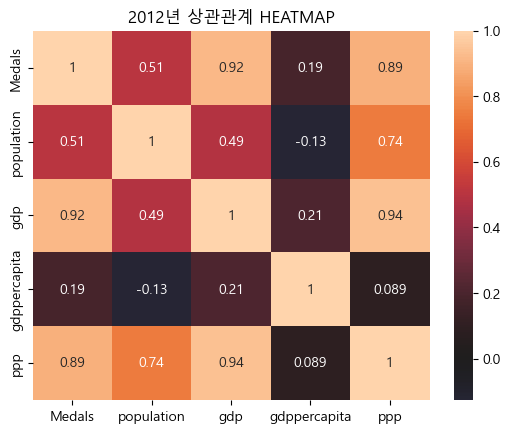

In [69]:
# 2012년 Heatmap과 데이터
sns.heatmap(df_2012[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2012년 상관관계 HEATMAP')
plt.show()

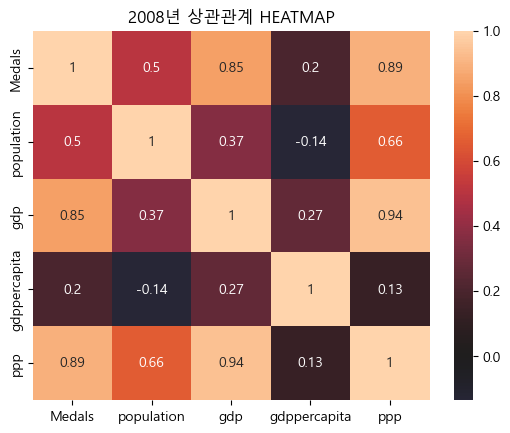

In [70]:
# 2008년 데이터 상관관계 HEATMAP

sns.heatmap(df_2008[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2008년 상관관계 HEATMAP')
plt.show()

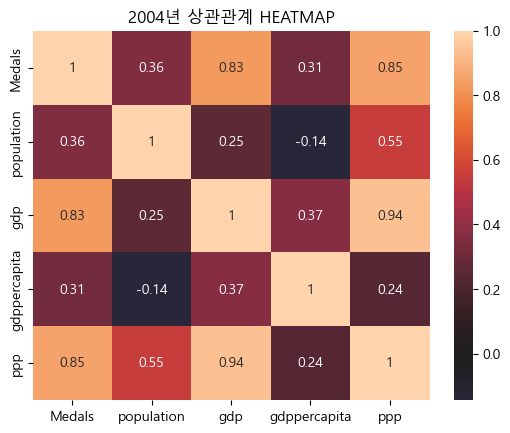

In [71]:
# 2004년 데이터 상관관계 HEATMAP

sns.heatmap(df_2004[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2004년 상관관계 HEATMAP')
plt.show()

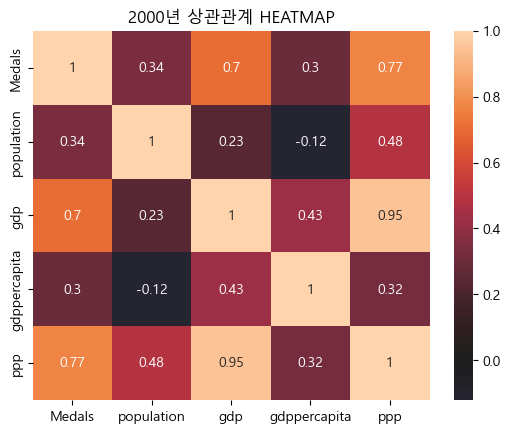

In [72]:
# 2000년 데이터 상관관계 HEATMAP
sns.heatmap(df_2000[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2000년 상관관계 HEATMAP')
plt.show()

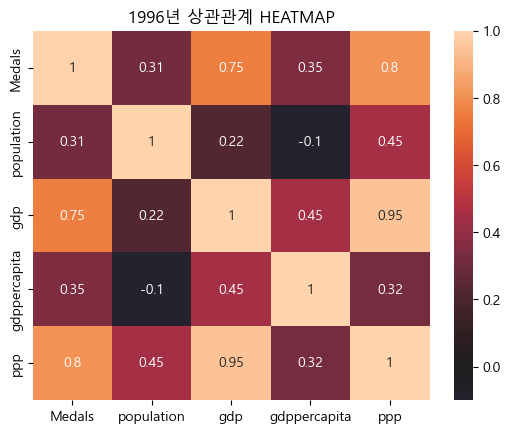

In [73]:
# 1996년 데이터 상관관계 HEATMAP
sns.heatmap(df_1996[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('1996년 상관관계 HEATMAP')
plt.show()

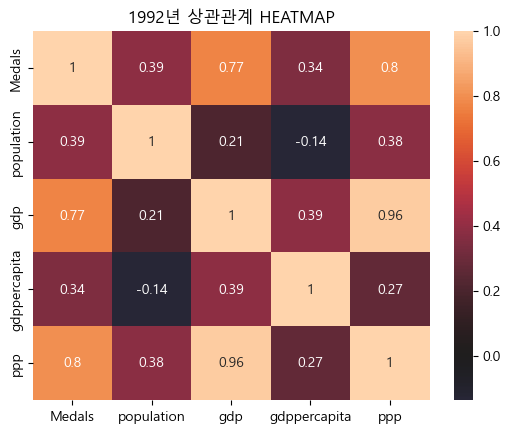

In [74]:
# 1992년 데이터 상관관계 HEATMAP
sns.heatmap(df_1992[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('1992년 상관관계 HEATMAP')
plt.show()

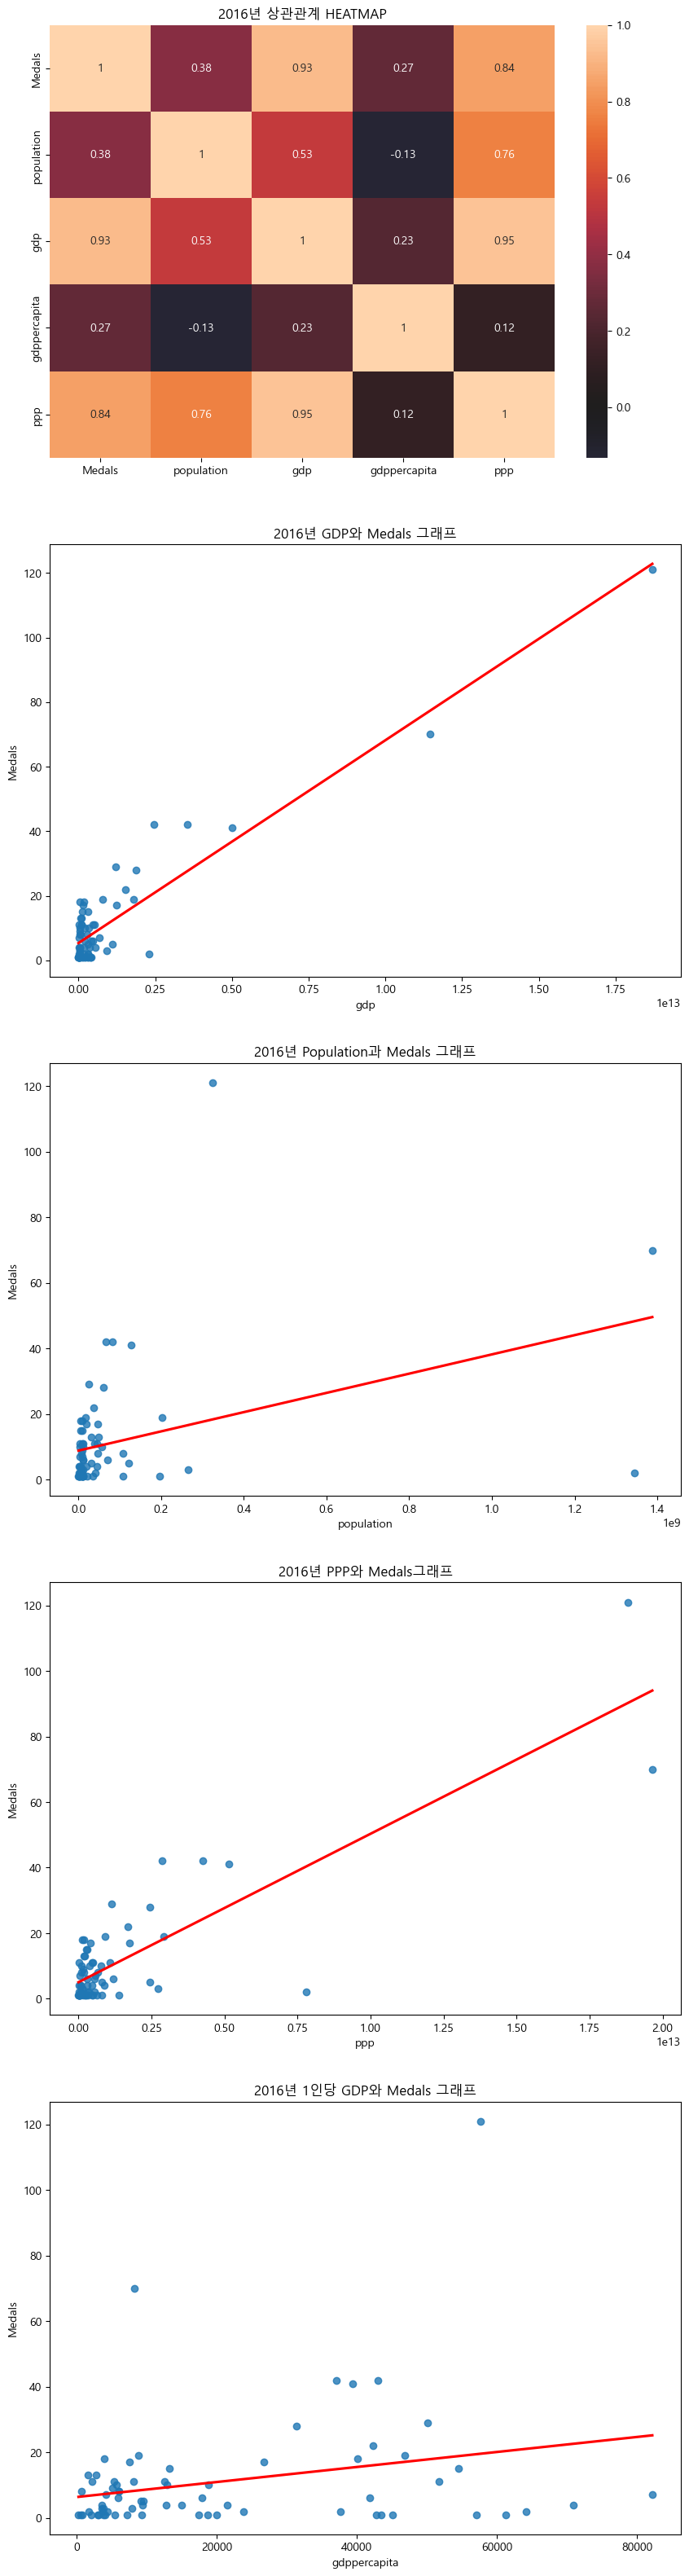

In [75]:
#2016년 상관관계 heatmap, regplot

fig,axes = plt.subplots(5,1,figsize=(10,40))
sns.heatmap(df_2016[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[0])
sns.regplot(data=df_2016,x='gdp',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[1])
sns.regplot(data=df_2016,x='population',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[2])
sns.regplot(data=df_2016,x='ppp',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[3])
sns.regplot(data=df_2016,x='gdppercapita',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[4])
axes[0].set_title('2016년 상관관계 HEATMAP')
axes[1].set_title('2016년 GDP와 Medals 그래프')
axes[2].set_title('2016년 Population과 Medals 그래프')
axes[3].set_title('2016년 PPP와 Medals그래프')
axes[4].set_title('2016년 1인당 GDP와 Medals 그래프')
plt.show()

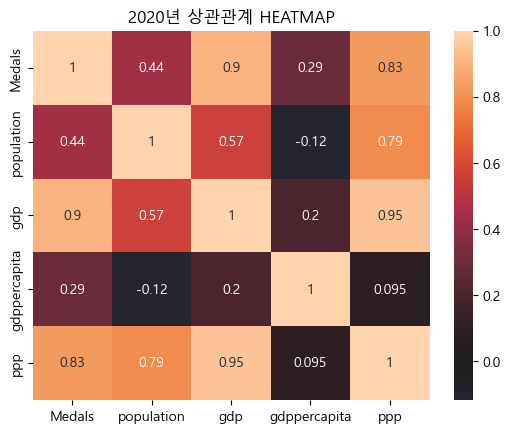

In [76]:
# 2020년 상관계수 HEATMAP
sns.heatmap(df_2020[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2020년 상관관계 HEATMAP')
plt.show()

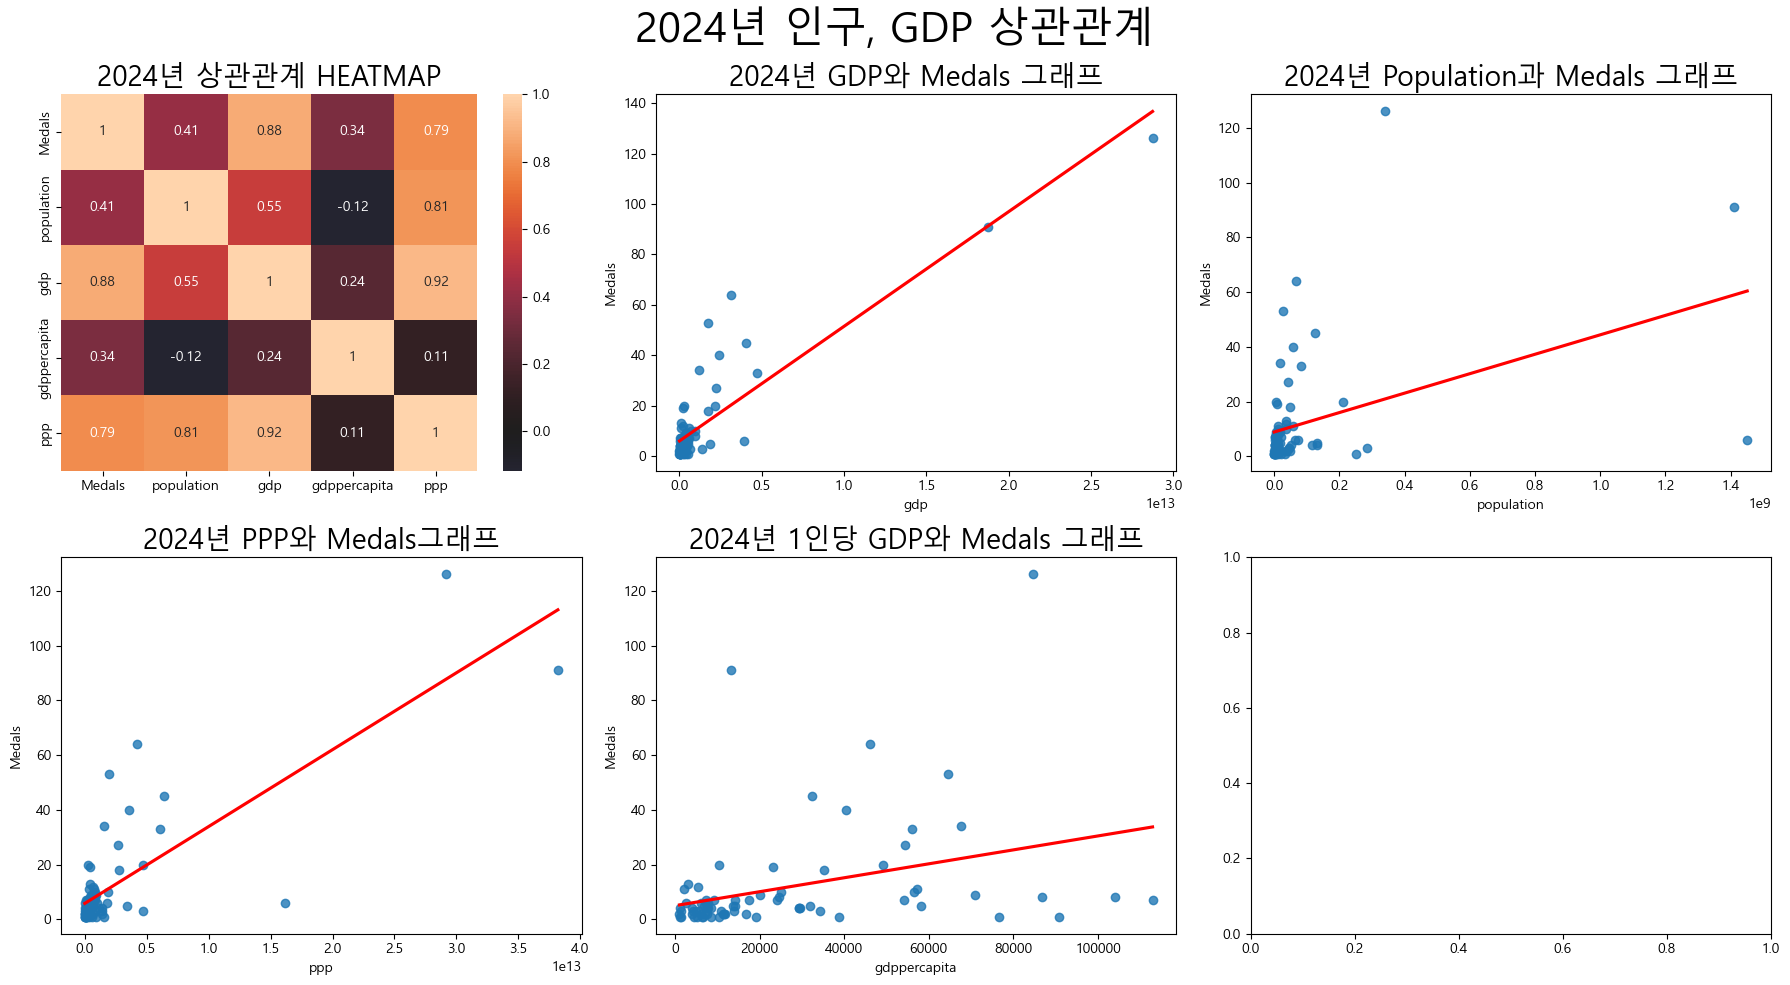

In [77]:
# 2024년 Heatmap regplot 그래프
fig,axes = plt.subplots(2,3,figsize=(18,10))
fig.suptitle('2024년 인구, GDP 상관관계',size = 30)
# regplot 차트 회귀선은 빨간색으로 설정
sns.heatmap(df_2024[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[0,0])
sns.regplot(data=df_2024,x='gdp',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[0,1])
sns.regplot(data=df_2024,x='population',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[0,2])
sns.regplot(data=df_2024,x='ppp',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[1,0])
sns.regplot(data=df_2024,x='gdppercapita',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[1,1])

# 차트 제목파트
axes[0,0].set_title('2024년 상관관계 HEATMAP',size=20)
axes[0,1].set_title('2024년 GDP와 Medals 그래프',size=20)
axes[0,2].set_title('2024년 Population과 Medals 그래프',size=20)
axes[1,0].set_title('2024년 PPP와 Medals그래프',size=20)
axes[1,1].set_title('2024년 1인당 GDP와 Medals 그래프',size=20)

plt.tight_layout()
plt.show()

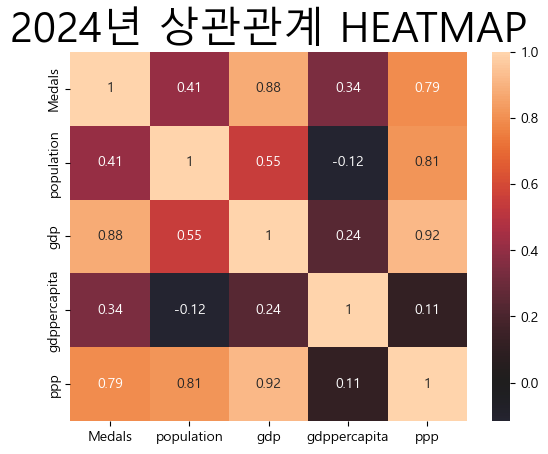

In [100]:
# 2024년 HEATMAP
sns.heatmap(df_2024[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2024년 상관관계 HEATMAP',size=30)
plt.show()

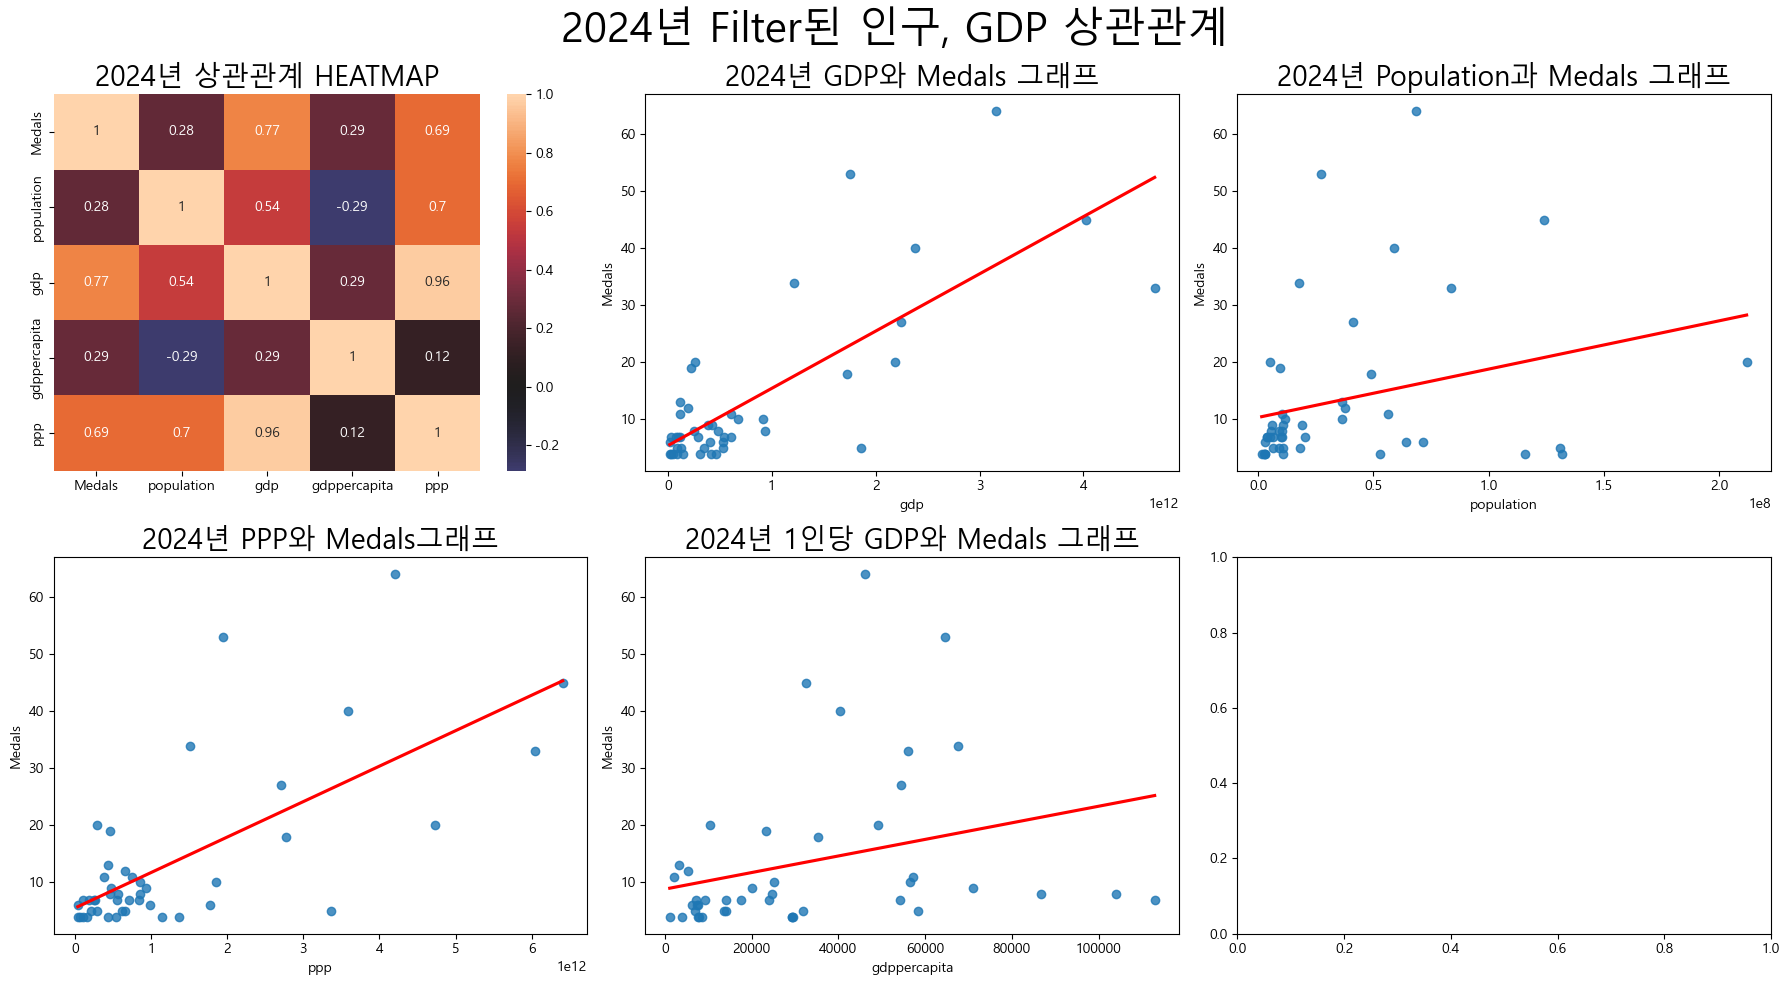

In [101]:
# 중국, 미국, 인도는 제외한다. 
strange = ['China','United States','India']
# 중국, 미국, 인도가 포함돈 것은 제외
df_2024_filter = df_2024[~df_2024['Country'].isin(strange)]
# 총 메달 수가 3개 초과만 필터링
df_2024_filter = df_2024_filter[df_2024_filter['Medals']>3]

fig,axes = plt.subplots(2,3,figsize=(18,10))
fig.suptitle('2024년 Filter된 인구, GDP 상관관계',size = 30)
sns.heatmap(df_2024_filter[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[0,0])
sns.regplot(data=df_2024_filter,x='gdp',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[0,1])
sns.regplot(data=df_2024_filter,x='population',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[0,2])
sns.regplot(data=df_2024_filter,x='ppp',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[1,0])
sns.regplot(data=df_2024_filter,x='gdppercapita',y='Medals',line_kws={"color":"red"},ci=None,ax=axes[1,1])
# 차트 제목 파트
axes[0,0].set_title('2024년 상관관계 HEATMAP',size=20)
axes[0,1].set_title('2024년 GDP와 Medals 그래프',size=20)
axes[0,2].set_title('2024년 Population과 Medals 그래프',size=20)
axes[1,0].set_title('2024년 PPP와 Medals그래프',size=20)
axes[1,1].set_title('2024년 1인당 GDP와 Medals 그래프',size=20)


plt.tight_layout()
plt.show()


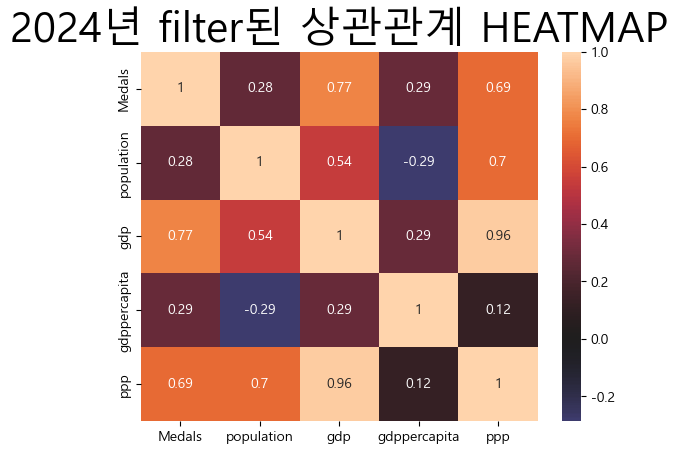

In [102]:
sns.heatmap(df_2024_filter[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2024년 filter된 상관관계 HEATMAP',size=30)
plt.show()

In [103]:
corr = df_2024[['Medals','population','gdp','gdppercapita','ppp']].corr()

corr1= corr.head(1)

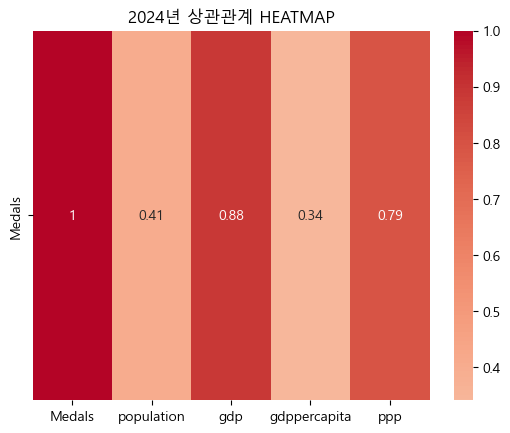

In [104]:
sns.heatmap(corr1,annot=True, cmap = 'coolwarm',center=0)
plt.title('2024년 상관관계 HEATMAP')
plt.show()

## 2. 종목별로 분리해서 시각화한다. 
### 고유값을 확인하고 리스트를 만들어서 전부 분류한다. 

In [105]:
# 고유값 확인

unique = df['Discipline'].unique()
print(unique)
print('총 고유값 개수',len(unique))

['Artistic Gymnastics' 'Athletics' 'Cycling Road' 'Cycling Track'
 'Fencing' 'Shooting' 'Swimming' 'Tennis' 'Weightlifting' 'Wrestling'
 'Archery' 'Basque pelota' 'Cricket' 'Croquet' 'Equestrian Dressage'
 'Equestrian Driving' 'Equestrian Jumping' 'Football' 'Golf' 'Polo'
 'Rowing' 'Rugby' 'Sailing' 'Tug-Of-War' 'Water Polo' 'Boxing' 'Diving'
 'Lacrosse' 'Roque' 'Figure Skating' 'Hockey' 'Jeu De Paume'
 'Motorboating' 'Racquets' 'Art Competitions' 'Equestrian Eventing'
 'Modern Pentathlon' 'Equestrian Vaulting' 'Ice Hockey' 'Alpinism'
 'Aeronautics' 'Basketball' 'Canoe Marathon' 'Canoe Sprint' 'Handball'
 'Judo' 'Volleyball' 'Canoe Slalom' 'Artistic Swimming'
 'Rhythmic Gymnastics' 'Table Tennis' 'Badminton' 'Baseball'
 'Beach Volleyball' 'Cycling Mountain Bike' 'Softball' 'Taekwondo'
 'Trampolining' 'Triathlon' 'Cycling BMX Racing' 'Marathon Swimming'
 'Rugby Sevens' '3x3 Basketball' 'Cycling BMX Freestyle' 'Karate'
 'Skateboarding' 'Sport Climbing' 'Surfing' 'Bobsleigh'
 'Cross Count

In [106]:
# 분류할 리스트를 만들어서 고유값 입력
water_sports = ['Artistic Swimming','Diving','Swimming','Water Polo',
                'Marathon Swimming','Surfing']
athletics = ['Artistic Gymnastics','Athletics','Rhythmic Gymnastics',
             'Trampolining','Triathlon','Trampoline Gymnastics']
ball = ['Beach Volleyball','Baseball','Basketball','Cricket',
        'Rugby Sevens','Football','Rugby','Handball','Badminton','Softball',
        'Table Tennis','Tennis','Golf','3x3 Basketball']
fight= ['Fencing','Wrestling','Boxing','Judo','Taekwondo','Wrestling','Karate']
shoot = ['Archery','Shooting']
cycle = ['Equestrian','Cycling BMX Freestyle','Cycling BMX Racing','Modern Pentathlon',
         'Equestrian Jumping','Cycling Track','Cycling Mountain Bike','Cycling Road',
         'Equestrian Dressage','Equestrian Eventing']
etc = ['Sport Climbing','Skateboarding','Weightlifting','Sailing',
       'Rowing','Canoe Slalom','Canoe Sprint']

# 총 분류에 몇 개가 있고 고유값 개수가 52개인지 확인하는 과정
print(len(water_sports))
print(len(athletics))
print(len(ball))
print(len(fight))
print(len(shoot))
print(len(cycle))
print(len(etc))


6
6
14
7
2
10
7


In [107]:
# 리스트에 있는 값만 isin()을 통해 추출하기
df_water = df[df['Discipline'].isin(water_sports)]
df_athletics = df[df['Discipline'].isin(athletics)]
df_ball = df[df['Discipline'].isin(ball)]
df_fight = df[df['Discipline'].isin(fight)]
df_shoot = df[df['Discipline'].isin(shoot)]
df_cycle = df[df['Discipline'].isin(cycle)]
df_etc = df[df['Discipline'].isin(etc)]

# 연도와 나라에 대해 그룹화하고 메달 타입에 대해 원소 갯수를 카운트한다. 그리고 결측치는 0으로 바꿔준다. 
# Medals에 Gold, Silver, Bronze의 총 합을 넣어준다. 
# 모든 분류에 대해 데이터프레임을 생성해준다. 
df_water2 = df_water.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_water2['Medals'] = df_water2['Bronze']+df_water2['Silver']+df_water2['Gold']

df_athletics2 = df_athletics.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_athletics2['Medals'] = df_athletics2['Bronze']+df_athletics2['Silver']+df_athletics2['Gold']

df_ball2 = df_ball.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_ball2['Medals'] = df_ball2['Bronze']+df_ball2['Silver']+df_ball2['Gold']

df_fight2 = df_fight.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_fight2['Medals'] = df_fight2['Bronze']+df_fight2['Silver']+df_fight2['Gold']

df_shoot2 = df_shoot.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_shoot2['Medals'] = df_shoot2['Bronze']+df_shoot2['Silver']+df_shoot2['Gold']

df_cycle2 = df_cycle.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_cycle2['Medals'] = df_cycle2['Bronze']+df_cycle2['Silver']+df_cycle2['Gold']

df_etc2 = df_etc.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_etc2['Medals'] = df_etc2['Bronze']+df_etc2['Silver']+df_etc2['Gold']

# 그룹화한 데이터를 다시 reset_index()함으로써 연도와 나라를 다시 열로 바꿔준다.(차트를 만들기 쉽게하기 위해)
df_water3 = df_water2.reset_index()
df_athletics3 = df_athletics2.reset_index()
df_ball3 = df_ball2.reset_index()
df_fight3 = df_fight2.reset_index()
df_shoot3 = df_shoot2.reset_index()
df_cycle3 = df_cycle2.reset_index()
df_etc3 = df_etc2.reset_index()



#### 2024년에 대해 종목을 분류하고 시각화

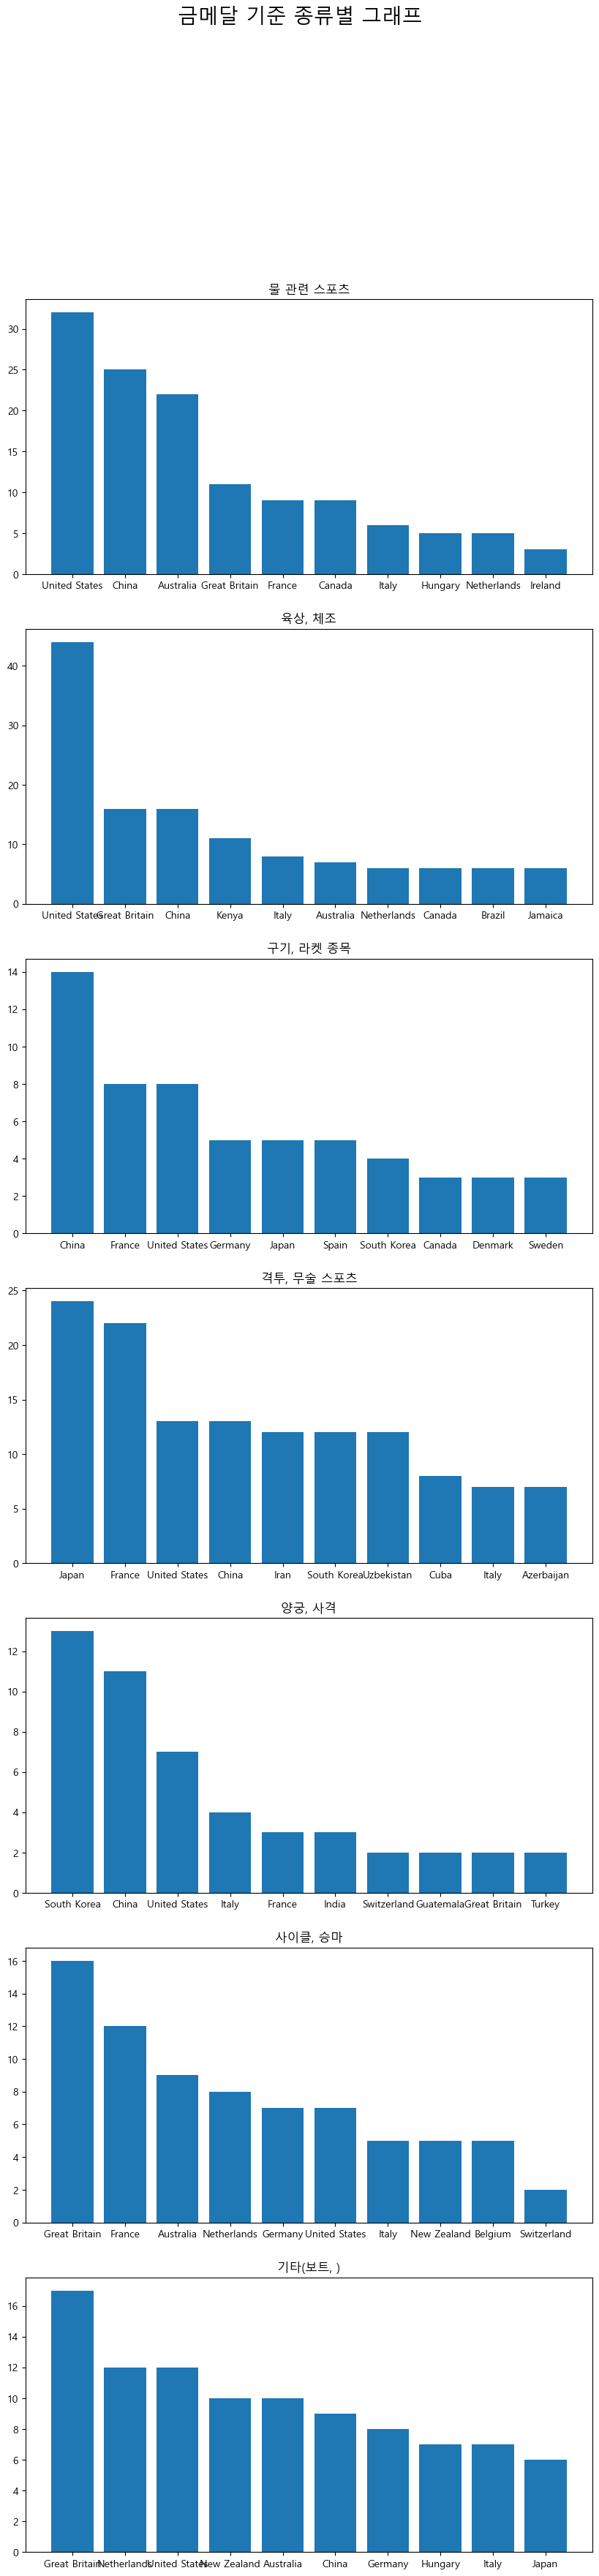

In [86]:
# 2024년에 대해 종목을 나누고 총 메달 수에 대해 내림차순 정렬한다. 
df_water_2024 = df_water3[df_water3['Olympic_year']==2024].sort_values('Medals',ascending=False)
df_athletics_2024 = df_athletics3[df_athletics3['Olympic_year']==2024].sort_values('Medals',ascending=False)
df_ball_2024 = df_ball3[df_ball3['Olympic_year']==2024].sort_values('Medals',ascending=False)
df_fight_2024 = df_fight3[df_fight3['Olympic_year']==2024].sort_values('Medals',ascending=False)
df_shoot_2024 = df_shoot3[df_shoot3['Olympic_year']==2024].sort_values('Medals',ascending=False)
df_cycle_2024 = df_cycle3[df_cycle3['Olympic_year']==2024].sort_values('Medals',ascending=False)
df_etc_2024 = df_etc3[df_etc3['Olympic_year']==2024].sort_values('Medals',ascending=False)

fig,axes = plt.subplots(7,1,figsize=(10,40))
fig.suptitle('금메달 기준 종류별 그래프',size=20)
axes[0].bar(df_water_2024.head(10)['Committee'],df_water_2024.head(10)['Medals'])
axes[0].set_title('물 관련 스포츠')
axes[1].bar(df_athletics_2024.head(10)['Committee'],df_athletics_2024.head(10)['Medals'])
axes[1].set_title('육상, 체조')
axes[2].bar(df_ball_2024.head(10)['Committee'],df_ball_2024.head(10)['Medals'])
axes[2].set_title('구기, 라켓 종목')
axes[3].bar(df_fight_2024.head(10)['Committee'],df_fight_2024.head(10)['Medals'])
axes[3].set_title('격투, 무술 스포츠')
axes[4].bar(df_shoot_2024.head(10)['Committee'],df_shoot_2024.head(10)['Medals'])
axes[4].set_title('양궁, 사격')
axes[5].bar(df_cycle_2024.head(10)['Committee'],df_cycle_2024.head(10)['Medals'])
axes[5].set_title('사이클, 승마')
axes[6].bar(df_etc_2024.head(10)['Committee'],df_etc_2024.head(10)['Medals'])
axes[6].set_title('기타(보트, )')

plt.show()


In [87]:
# 만들어진 데이터프레임을 2024년 채택하고 총메달에 대해 내림차순하고 상위 10개행만 뽑고,Bronze,Silver,Gold열만 뽑는다. 
df_water_2024 = df_water3[df_water3['Olympic_year']==2024].sort_values('Medals',ascending=False).set_index('Committee').head(10)[['Bronze','Silver','Gold']]
df_athletics_2024 = df_athletics3[df_athletics3['Olympic_year']==2024].sort_values('Medals',ascending=False).set_index('Committee').head(10)[['Bronze','Silver','Gold']]
df_ball_2024 = df_ball3[df_ball3['Olympic_year']==2024].sort_values('Medals',ascending=False).set_index('Committee').head(10)[['Bronze','Silver','Gold']]
df_fight_2024 = df_fight3[df_fight3['Olympic_year']==2024].sort_values('Medals',ascending=False).set_index('Committee').head(10)[['Bronze','Silver','Gold']]
df_shoot_2024 = df_shoot3[df_shoot3['Olympic_year']==2024].sort_values('Medals',ascending=False).set_index('Committee').head(10)[['Bronze','Silver','Gold']]
df_cycle_2024 = df_cycle3[df_cycle3['Olympic_year']==2024].sort_values('Medals',ascending=False).set_index('Committee').head(10)[['Bronze','Silver','Gold']]
df_etc_2024 = df_etc3[df_etc3['Olympic_year']==2024].sort_values('Medals',ascending=False).set_index('Committee').head(10)[['Bronze','Silver','Gold']]


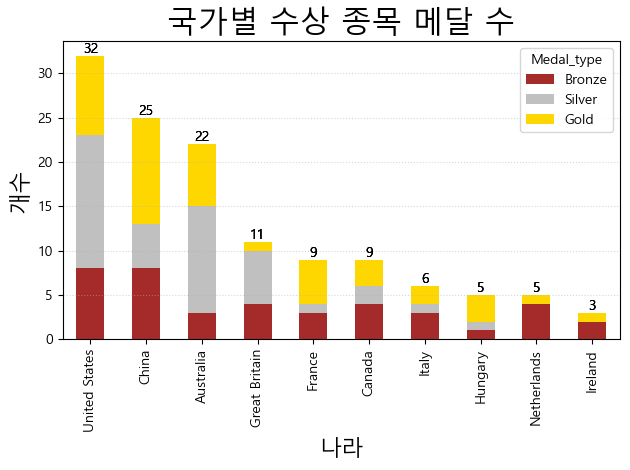

In [88]:
# 물 관련 스포츠 그래프
ax = df_water_2024.plot(kind='bar',stacked=True,color=['brown','silver','gold']) # 그래프 그리기

for container in ax.containers: # 숫자를 표시하는 법
    ax.bar_label(ax.containers[-1],label_type='edge') # 전체 합계만 숫자 표시할 수 있다. 
    
#for bar	in ax.patches:
#	plt.text(bar.get_x() + bar.get_width()/2,bar.get_height(),f'{bar.get_height():.2f}',ha='center',va='bottom',fontsize=12)

plt.title('국가별 수상 종목 메달 수',size=22)
plt.grid(True,axis='y',linestyle = ':',alpha=0.5)
plt.xlabel('나라',size=16)
plt.ylabel('개수',size=16)
plt.tight_layout()
plt.show()



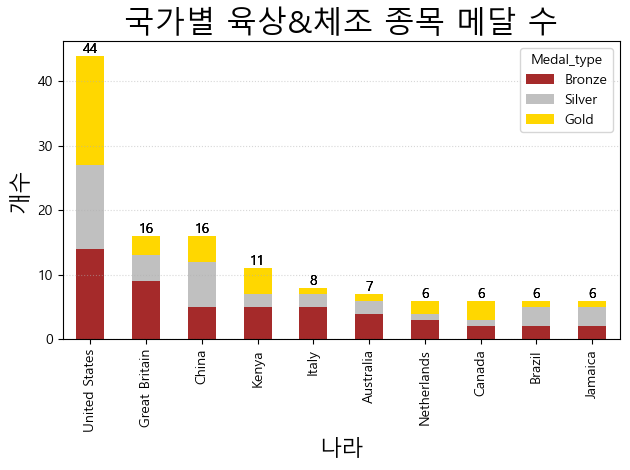

In [89]:
# 육상 체조 관련 스포츠 그래프
ax = df_athletics_2024.plot(kind='bar',stacked=True,color=['brown','silver','gold'])# 그래프 그리기

for container in ax.containers: # 숫자를 표시하는 법
    ax.bar_label(ax.containers[-1],label_type='edge') # 전체 합계만 숫자 표시

plt.title('국가별 육상&체조 종목 메달 수',size=22)
plt.grid(True,axis='y',linestyle = ':',alpha=0.5)
plt.xlabel('나라',size=16)
plt.ylabel('개수',size=16)
plt.tight_layout()
plt.show()


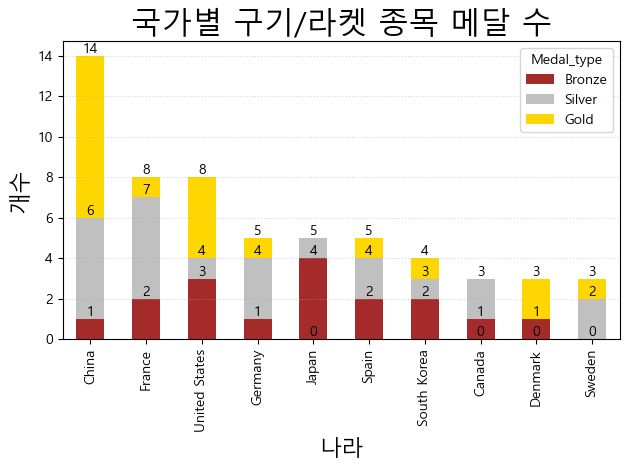

In [90]:
# 구기 종목 관련 스포츠 그래프
ax = df_ball_2024.plot(kind='bar',stacked=True,color=['brown','silver','gold'])# 그래프 그리기

for container in ax.containers: # 숫자를 표시하는 법
    ax.bar_label(container,label_type='edge') # contaner[-1]이면 Gold가 0일때 0으로 나와서 이렇게 설정

plt.title('국가별 구기/라켓 종목 메달 수',size=22)
plt.grid(True,axis='y',linestyle = ':',alpha=0.5)
plt.xlabel('나라',size=16)
plt.ylabel('개수',size=16)
plt.tight_layout()
plt.show()

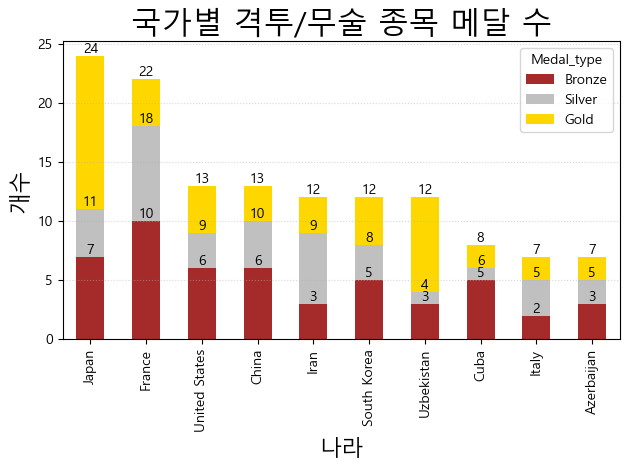

In [91]:
# 격투 종목 관련 스포츠 그래프
ax = df_fight_2024.plot(kind='bar',stacked=True,color=['brown','silver','gold'])# 그래프 그리기

for container in ax.containers: # 숫자를 표시하는 법
    ax.bar_label(container,label_type='edge') # contaner[-1]이면 Gold가 0일때 0으로 나와서 이렇게 설정

plt.title('국가별 격투/무술 종목 메달 수',size=22)
plt.grid(True,axis='y',linestyle = ':',alpha=0.5)
plt.xlabel('나라',size=16)
plt.ylabel('개수',size=16)
plt.tight_layout()
plt.show()

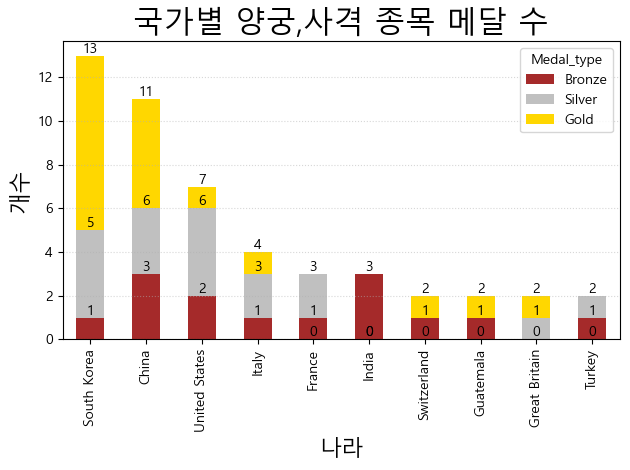

In [92]:
# 양궁,사격 종목 관련 스포츠 그래프
ax = df_shoot_2024.plot(kind='bar',stacked=True,color=['brown','silver','gold'])# 그래프 그리기

for container in ax.containers: # 숫자를 표시하는 법
    ax.bar_label(container,label_type='edge') # contaner[-1]이면 Gold가 0일때 0으로 나와서 이렇게 설정

plt.title('국가별 양궁,사격 종목 메달 수',size=22)
plt.grid(True,axis='y',linestyle = ':',alpha=0.5)
plt.xlabel('나라',size=16)
plt.ylabel('개수',size=16)
plt.tight_layout()
plt.show()

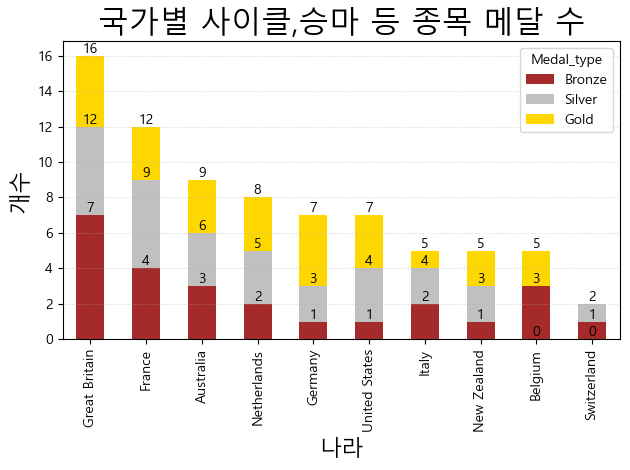

In [93]:
# 사이클, 승마 종목 관련 스포츠 그래프
ax = df_cycle_2024.plot(kind='bar',stacked=True,color=['brown','silver','gold'])# 그래프 그리기

for container in ax.containers: # 숫자를 표시하는 법
    ax.bar_label(container,label_type='edge') # contaner[-1]이면 Gold가 0일때 0으로 나와서 이렇게 설정

plt.title('국가별 사이클,승마 등 종목 메달 수',size=22)
plt.grid(True,axis='y',linestyle = ':',alpha=0.5)
plt.xlabel('나라',size=16)
plt.ylabel('개수',size=16)
plt.tight_layout()
plt.show()

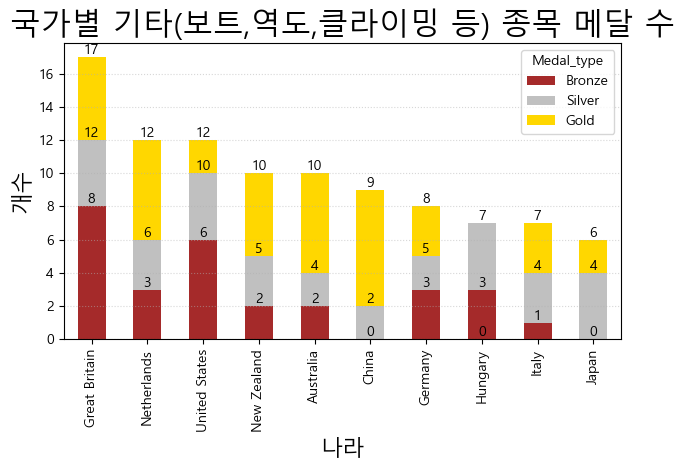

In [94]:
# 기타(보트,역도,클라이밍 등) 종목 관련 스포츠 그래프
ax = df_etc_2024.plot(kind='bar',stacked=True,color=['brown','silver','gold'])# 그래프 그리기

for container in ax.containers: # 숫자를 표시하는 법
    ax.bar_label(container,label_type='edge') # contaner[-1]이면 Gold가 0일때 0으로 나와서 이렇게 설정

plt.title('국가별 기타(보트,역도,클라이밍 등) 종목 메달 수',size=22)
plt.grid(True,axis='y',linestyle = ':',alpha=0.5)
plt.xlabel('나라',size=16)
plt.ylabel('개수',size=16)
plt.tight_layout()
plt.show()

### 연도별 총 메달 수에 대한 파이 차트를 그려보기

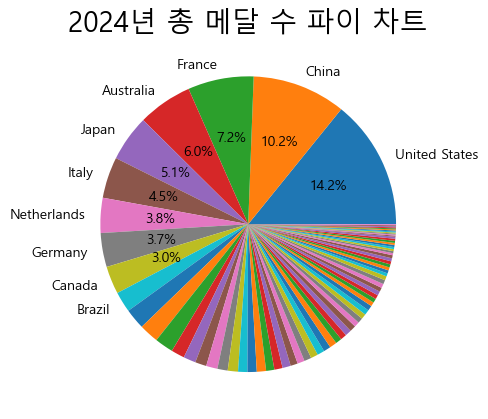

In [117]:
#
df_2024_sort = df_2024.sort_values('Medals',ascending=False)
total = sum(df_2024_sort['Medals'])


plt.pie(df_2024_sort['Medals'],
        labels=[label if i<10 else '' for i,label in enumerate(df_2024_sort['Country'])],# 상위 10개 항목만 label 넣기
        autopct=lambda p:f'{p:.1f}%' if p>=3 else'', # 3퍼센트 이상만 퍼센트 넣기
        )
plt.title('2024년 총 메달 수 파이 차트',size=20)
plt.show()

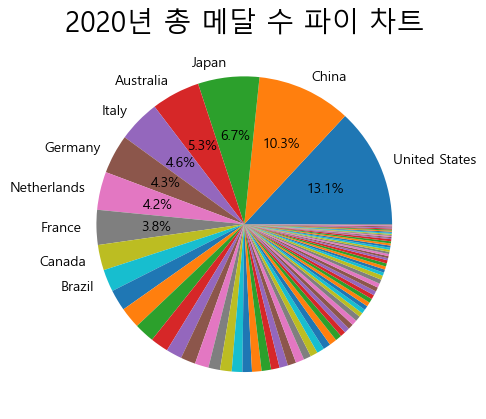

In [ ]:
df_2020_sort = df_2020.sort_values('Medals',ascending=False)
total = sum(df_2020_sort['Medals'])


plt.pie(df_2020_sort['Medals'],
        labels=[label if i<10 else '' for i,label in enumerate(df_2020_sort['Country'])], # 상위 10개 항목만 label 넣기
        autopct=lambda p:f'{p:.1f}%' if p>=3 else'', # 3퍼센트 이상만 퍼센트 넣기
        )
plt.title('2020년 총 메달 수 파이 차트',size=20)
plt.show()

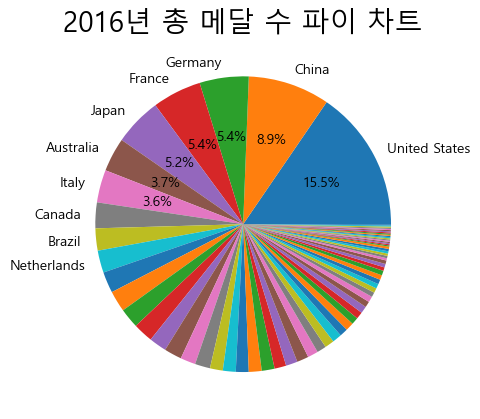

In [ ]:
df_2016_sort = df_2016.sort_values('Medals',ascending=False)
total = sum(df_2016_sort['Medals'])


plt.pie(df_2016_sort['Medals'],
        labels=[label if i<10 else '' for i,label in enumerate(df_2016_sort['Country'])],# 상위 10개 항목만 label 넣기
        autopct=lambda p:f'{p:.1f}%' if p>=3 else'',# 3퍼센트 이상만 퍼센트 넣기
        )
plt.title('2016년 총 메달 수 파이 차트',size=20)
plt.show()

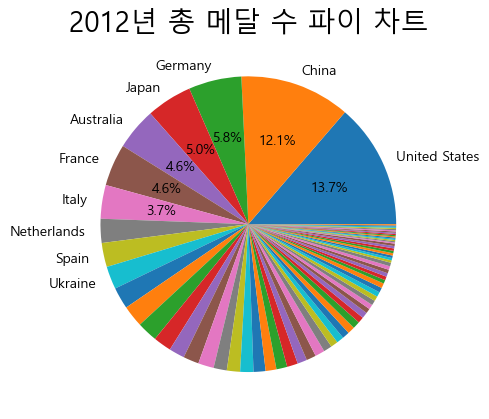

In [ ]:
df_2012_sort = df_2012.sort_values('Medals',ascending=False)
total = sum(df_2012_sort['Medals'])


plt.pie(df_2012_sort['Medals'],
        labels=[label if i<10 else '' for i,label in enumerate(df_2012_sort['Country'])],# 상위 10개 항목만 label 넣기
        autopct=lambda p:f'{p:.1f}%' if p>=3 else'', # 3퍼센트 이상만 퍼센트 넣기
        )
plt.title('2012년 총 메달 수 파이 차트',size=20)
plt.show()

### 종목을 분류해보고 분류된 종목에 해당하는 데이터프레임에서 GDP,1인당GDP,PPP, 인구와의 상관관계를 찾는다.

In [109]:

df3 = df[df['Olympic_year']==2024]

# 리스트에 있는 값만 isin()을 통해 추출하기
df_water_20242 = df3[df3['Discipline'].isin(water_sports)]
df_athletics_20242 = df3[df3['Discipline'].isin(athletics)]
df_ball_20242 = df3[df3['Discipline'].isin(ball)]
df_fight_20242 = df3[df3['Discipline'].isin(fight)]
df_shoot_20242 = df3[df3['Discipline'].isin(shoot)]
df_cycle_20242 = df3[df3['Discipline'].isin(cycle)]
df_etc_20242 = df3[df3['Discipline'].isin(etc)]

# 연도와 나라에 대해 그룹화하고 메달 타입에 대해 원소 갯수를 카운트한다. 그리고 결측치는 0으로 바꿔준다. 
# Medals에 Gold, Silver, Bronze의 총 합을 넣어준다. 
# 모든 분류에 대해 데이터프레임을 생성해준다. 
df_water_20242 = df_water_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_water_20242['Medals'] = df_water_20242['Bronze']+df_water_20242['Silver']+df_water_20242['Gold']

df_athletics_20242 = df_athletics_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_athletics_20242['Medals'] = df_athletics_20242['Bronze']+df_athletics_20242['Silver']+df_athletics_20242['Gold']

df_ball_20242 = df_ball_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_ball_20242['Medals'] = df_ball_20242['Bronze']+df_ball_20242['Silver']+df_ball_20242['Gold']

df_fight_20242 = df_fight_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_fight_20242['Medals'] = df_fight_20242['Bronze']+df_fight_20242['Silver']+df_fight_20242['Gold']

df_shoot_20242 = df_shoot_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_shoot_20242['Medals'] = df_shoot_20242['Bronze']+df_shoot_20242['Silver']+df_shoot_20242['Gold']

df_cycle_20242 = df_cycle_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_cycle_20242['Medals'] = df_cycle_20242['Bronze']+df_cycle_20242['Silver']+df_cycle_20242['Gold']

df_etc_20242 = df_etc_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_etc_20242['Medals'] = df_etc_20242['Bronze']+df_etc_20242['Silver']+df_etc_20242['Gold']

# 그룹화한 데이터를 다시 reset_index()함으로써 연도와 나라를 다시 열로 바꿔준다.(차트를 만들기 쉽게하기 위해)
df_water_20242 = df_water_20242.reset_index()
df_athletics_20242 = df_athletics_20242.reset_index()
df_ball_20242 = df_ball_20242.reset_index()
df_fight_20242 = df_fight_20242.reset_index()
df_shoot_20242 = df_shoot_20242.reset_index()
df_cycle_20242 = df_cycle_20242.reset_index()
df_etc_20242 = df_etc_20242.reset_index()

# 2024년에 대해 종목을 나누고 총 메달 수에 대해 내림차순 정렬한다. 
df_water_20242 = df_water_20242.sort_values('Medals',ascending=False)
df_athletics_20242 = df_athletics_20242.sort_values('Medals',ascending=False)
df_ball_20242 = df_ball_20242.sort_values('Medals',ascending=False)
df_fight_20242 = df_fight_20242.sort_values('Medals',ascending=False)
df_shoot_20242 = df_shoot_20242.sort_values('Medals',ascending=False)
df_cycle_20242 = df_cycle_20242.sort_values('Medals',ascending=False)
df_etc_20242 = df_etc_20242.sort_values('Medals',ascending=False)


df_gdp2024 = df_gdp[['Country Name','2024']]
df_gdp2024 = df_gdp2024.rename(columns={'Country Name':'Committee','2024':'gdp'})

df_population2024 = df_population[['Country Name','2024']]
df_population2024 = df_population2024.rename(columns={'Country Name':'Committee','2024':'population'})

df_gdppercapita2024 = df_gdppercapita[['Country Name','2024']]
df_gdppercapita2024 = df_gdppercapita2024.rename(columns={'Country Name':'Committee','2024':'gdppercapita'})

df_ppp2024 = df_ppp[['Country Name','2024']]
df_ppp2024 = df_ppp2024.rename(columns={'Country Name':'Committee','2024':'ppp'})

# water에 대해 
df_water_20242 = pd.merge(df_water_20242,df_population2024,on='Committee',how='inner')
df_water_20242 = pd.merge(df_water_20242,df_gdp2024,on='Committee',how='inner')
df_water_20242 = pd.merge(df_water_20242,df_gdppercapita2024,on='Committee',how='inner')
df_water_20242 = pd.merge(df_water_20242,df_ppp2024,on='Committee',how='inner')

# athletics에 대해 
df_athletics_20242 = pd.merge(df_athletics_20242,df_population2024,on='Committee',how='inner')
df_athletics_20242 = pd.merge(df_athletics_20242,df_gdp2024,on='Committee',how='inner')
df_athletics_20242 = pd.merge(df_athletics_20242,df_gdppercapita2024,on='Committee',how='inner')
df_athletics_20242 = pd.merge(df_athletics_20242,df_ppp2024,on='Committee',how='inner')

# ball에 대해 
df_ball_20242 = pd.merge(df_ball_20242,df_population2024,on='Committee',how='inner')
df_ball_20242 = pd.merge(df_ball_20242,df_gdp2024,on='Committee',how='inner')
df_ball_20242 = pd.merge(df_ball_20242,df_gdppercapita2024,on='Committee',how='inner')
df_ball_20242 = pd.merge(df_ball_20242,df_ppp2024,on='Committee',how='inner')

# fight에 대해 
df_fight_20242 = pd.merge(df_fight_20242,df_population2024,on='Committee',how='inner')
df_fight_20242 = pd.merge(df_fight_20242,df_gdp2024,on='Committee',how='inner')
df_fight_20242 = pd.merge(df_fight_20242,df_gdppercapita2024,on='Committee',how='inner')
df_fight_20242 = pd.merge(df_fight_20242,df_ppp2024,on='Committee',how='inner')

# shoot에 대해 
df_shoot_20242 = pd.merge(df_shoot_20242,df_population2024,on='Committee',how='inner')
df_shoot_20242 = pd.merge(df_shoot_20242,df_gdp2024,on='Committee',how='inner')
df_shoot_20242 = pd.merge(df_shoot_20242,df_gdppercapita2024,on='Committee',how='inner')
df_shoot_20242 = pd.merge(df_shoot_20242,df_ppp2024,on='Committee',how='inner')

# cycle에 대해 
df_cycle_20242 = pd.merge(df_cycle_20242,df_population2024,on='Committee',how='inner')
df_cycle_20242 = pd.merge(df_cycle_20242,df_gdp2024,on='Committee',how='inner')
df_cycle_20242 = pd.merge(df_cycle_20242,df_gdppercapita2024,on='Committee',how='inner')
df_cycle_20242 = pd.merge(df_cycle_20242,df_ppp2024,on='Committee',how='inner')

# etc에 대해 
df_etc_20242 = pd.merge(df_etc_20242,df_population2024,on='Committee',how='inner')
df_etc_20242 = pd.merge(df_etc_20242,df_gdp2024,on='Committee',how='inner')
df_etc_20242 = pd.merge(df_etc_20242,df_gdppercapita2024,on='Committee',how='inner')
df_etc_20242 = pd.merge(df_etc_20242,df_ppp2024,on='Committee',how='inner')



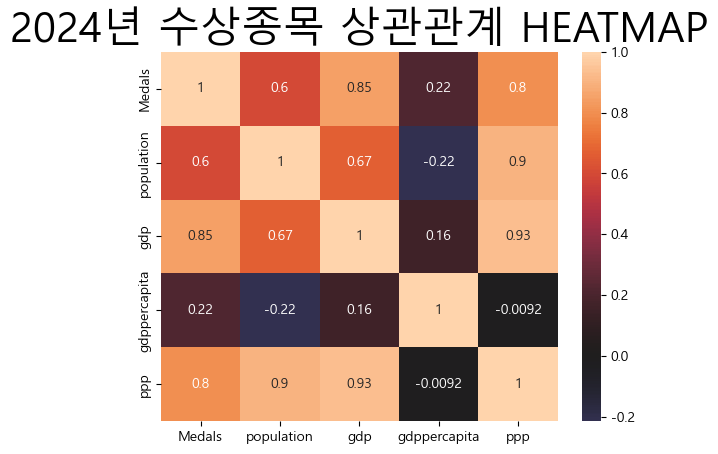

In [110]:
# 수상 종목 상관계수 Heatmap
sns.heatmap(df_water_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2024년 수상종목 상관관계 HEATMAP',size=30)
plt.show()

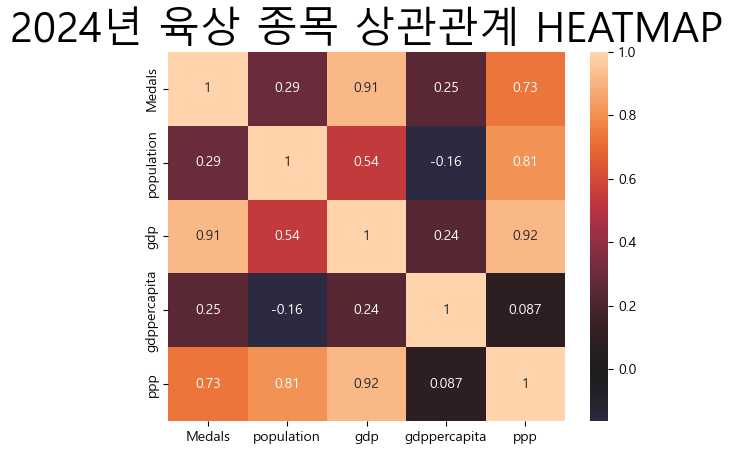

In [111]:
# 육상 종목 상관계수 Heatmap
sns.heatmap(df_athletics_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2024년 육상 종목 상관관계 HEATMAP',size=30)
plt.show()

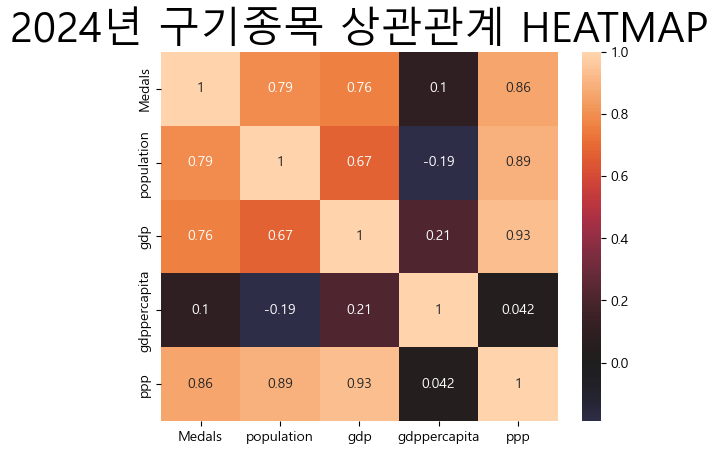

In [112]:
# 구기 종목 상관계수 Heatmap
sns.heatmap(df_ball_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2024년 구기종목 상관관계 HEATMAP',size=30)
plt.show()

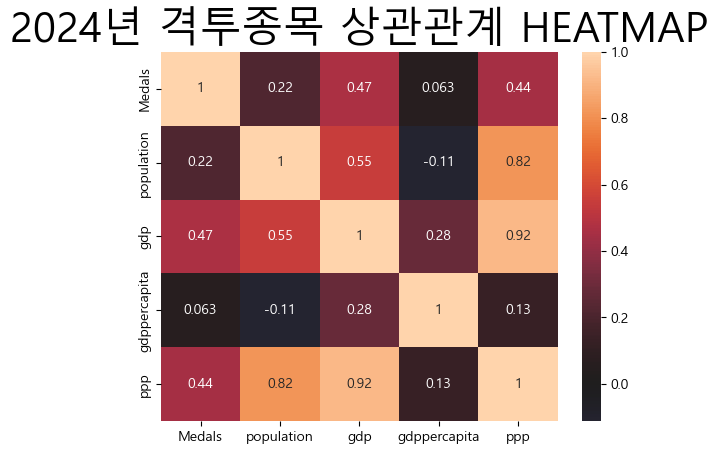

In [113]:
# 격투 종목 상관계수 Heatmap
sns.heatmap(df_fight_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2024년 격투종목 상관관계 HEATMAP',size=30)
plt.show()

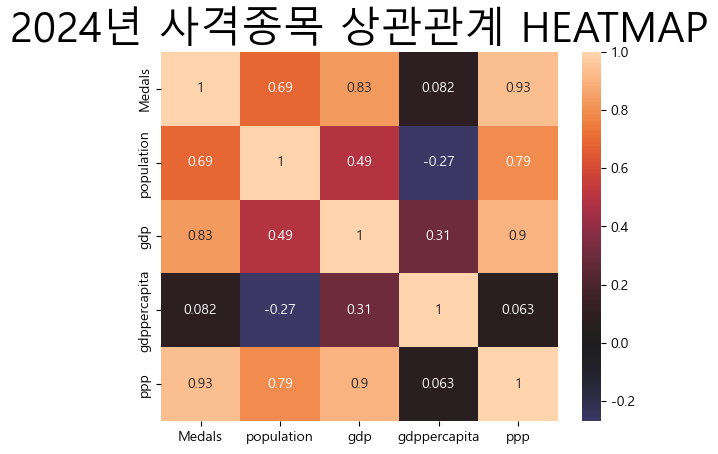

In [114]:
# 사격 종목 상관계수 Heatmap
sns.heatmap(df_shoot_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2024년 사격종목 상관관계 HEATMAP',size=30)
plt.show()

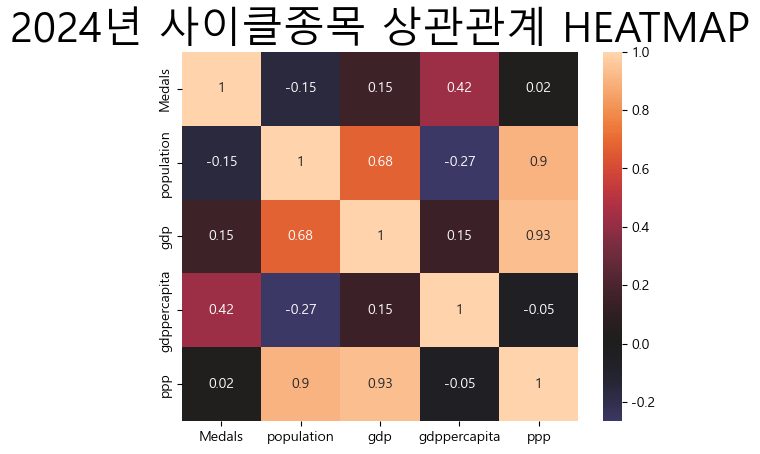

In [115]:
# 사이클 종목 상관계수 Heatmap
sns.heatmap(df_cycle_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2024년 사이클종목 상관관계 HEATMAP',size=30)
plt.show()

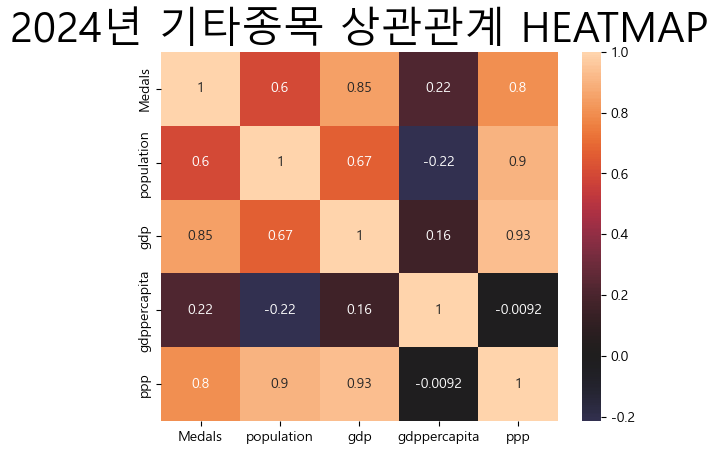

In [116]:
# 기타 종목 상관계수 Heatmap
sns.heatmap(df_water_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0)
plt.title('2024년 기타종목 상관관계 HEATMAP',size=30)
plt.show()

### 2020년에 대해도 똑같이 해보자

In [118]:
df3 = df[df['Olympic_year']==2020]

# 리스트에 있는 값만 isin()을 통해 추출하기
df_water_20202 = df3[df3['Discipline'].isin(water_sports)]
df_athletics_20202 = df3[df3['Discipline'].isin(athletics)]
df_ball_20202 = df3[df3['Discipline'].isin(ball)]
df_fight_20202 = df3[df3['Discipline'].isin(fight)]
df_shoot_20202 = df3[df3['Discipline'].isin(shoot)]
df_cycle_20202 = df3[df3['Discipline'].isin(cycle)]
df_etc_20202 = df3[df3['Discipline'].isin(etc)]

# 연도와 나라에 대해 그룹화하고 메달 타입에 대해 원소 갯수를 카운트한다. 그리고 결측치는 0으로 바꿔준다. 
# Medals에 Gold, Silver, Bronze의 총 합을 넣어준다. 
# 모든 분류에 대해 데이터프레임을 생성해준다. 
df_water_20202 = df_water_20202.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_water_20202['Medals'] = df_water_20202['Bronze']+df_water_20202['Silver']+df_water_20202['Gold']

df_athletics_20202 = df_athletics_20202.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_athletics_20202['Medals'] = df_athletics_20202['Bronze']+df_athletics_20202['Silver']+df_athletics_20202['Gold']

df_ball_20202 = df_ball_20202.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_ball_20202['Medals'] = df_ball_20202['Bronze']+df_ball_20202['Silver']+df_ball_20202['Gold']

df_fight_20202 = df_fight_20202.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_fight_20202['Medals'] = df_fight_20202['Bronze']+df_fight_20202['Silver']+df_fight_20202['Gold']

df_shoot_20202 = df_shoot_20202.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_shoot_20202['Medals'] = df_shoot_20202['Bronze']+df_shoot_20202['Silver']+df_shoot_20202['Gold']

df_cycle_20202 = df_cycle_20202.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_cycle_20202['Medals'] = df_cycle_20202['Bronze']+df_cycle_20202['Silver']+df_cycle_20202['Gold']

df_etc_20202 = df_etc_20202.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_etc_20202['Medals'] = df_etc_20202['Bronze']+df_etc_20202['Silver']+df_etc_20202['Gold']

# 그룹화한 데이터를 다시 reset_index()함으로써 연도와 나라를 다시 열로 바꿔준다.(차트를 만들기 쉽게하기 위해)
df_water_20202 = df_water_20202.reset_index()
df_athletics_20202 = df_athletics_20202.reset_index()
df_ball_20202 = df_ball_20202.reset_index()
df_fight_20202 = df_fight_20202.reset_index()
df_shoot_20202 = df_shoot_20202.reset_index()
df_cycle_20202 = df_cycle_20202.reset_index()
df_etc_20202 = df_etc_20202.reset_index()

# 2020년에 대해 종목을 나누고 총 메달 수에 대해 내림차순 정렬한다. 
df_water_20202 = df_water_20202.sort_values('Medals',ascending=False)
df_athletics_20202 = df_athletics_20202.sort_values('Medals',ascending=False)
df_ball_20202 = df_ball_20202.sort_values('Medals',ascending=False)
df_fight_20202 = df_fight_20202.sort_values('Medals',ascending=False)
df_shoot_20202 = df_shoot_20202.sort_values('Medals',ascending=False)
df_cycle_20202 = df_cycle_20202.sort_values('Medals',ascending=False)
df_etc_20202 = df_etc_20202.sort_values('Medals',ascending=False)


df_gdp2020 = df_gdp[['Country Name','2020']]
df_gdp2020 = df_gdp2020.rename(columns={'Country Name':'Committee','2020':'gdp'})

df_population2020 = df_population[['Country Name','2020']]
df_population2020 = df_population2020.rename(columns={'Country Name':'Committee','2020':'population'})

df_gdppercapita2020 = df_gdppercapita[['Country Name','2020']]
df_gdppercapita2020 = df_gdppercapita2020.rename(columns={'Country Name':'Committee','2020':'gdppercapita'})

df_ppp2020 = df_ppp[['Country Name','2020']]
df_ppp2020 = df_ppp2020.rename(columns={'Country Name':'Committee','2020':'ppp'})

# water에 대해 
df_water_20202 = pd.merge(df_water_20202,df_population2020,on='Committee',how='inner')
df_water_20202 = pd.merge(df_water_20202,df_gdp2020,on='Committee',how='inner')
df_water_20202 = pd.merge(df_water_20202,df_gdppercapita2020,on='Committee',how='inner')
df_water_20202 = pd.merge(df_water_20202,df_ppp2020,on='Committee',how='inner')

# athletics에 대해 
df_athletics_20202 = pd.merge(df_athletics_20202,df_population2020,on='Committee',how='inner')
df_athletics_20202 = pd.merge(df_athletics_20202,df_gdp2020,on='Committee',how='inner')
df_athletics_20202 = pd.merge(df_athletics_20202,df_gdppercapita2020,on='Committee',how='inner')
df_athletics_20202 = pd.merge(df_athletics_20202,df_ppp2020,on='Committee',how='inner')

# ball에 대해 
df_ball_20202 = pd.merge(df_ball_20202,df_population2020,on='Committee',how='inner')
df_ball_20202 = pd.merge(df_ball_20202,df_gdp2020,on='Committee',how='inner')
df_ball_20202 = pd.merge(df_ball_20202,df_gdppercapita2020,on='Committee',how='inner')
df_ball_20202 = pd.merge(df_ball_20202,df_ppp2020,on='Committee',how='inner')

# fight에 대해 
df_fight_20202 = pd.merge(df_fight_20202,df_population2020,on='Committee',how='inner')
df_fight_20202 = pd.merge(df_fight_20202,df_gdp2020,on='Committee',how='inner')
df_fight_20202 = pd.merge(df_fight_20202,df_gdppercapita2020,on='Committee',how='inner')
df_fight_20202 = pd.merge(df_fight_20202,df_ppp2020,on='Committee',how='inner')

# shoot에 대해 
df_shoot_20202 = pd.merge(df_shoot_20202,df_population2020,on='Committee',how='inner')
df_shoot_20202 = pd.merge(df_shoot_20202,df_gdp2020,on='Committee',how='inner')
df_shoot_20202 = pd.merge(df_shoot_20202,df_gdppercapita2020,on='Committee',how='inner')
df_shoot_20202 = pd.merge(df_shoot_20202,df_ppp2020,on='Committee',how='inner')

# cycle에 대해 
df_cycle_20202 = pd.merge(df_cycle_20202,df_population2020,on='Committee',how='inner')
df_cycle_20202 = pd.merge(df_cycle_20202,df_gdp2020,on='Committee',how='inner')
df_cycle_20202 = pd.merge(df_cycle_20202,df_gdppercapita2020,on='Committee',how='inner')
df_cycle_20202 = pd.merge(df_cycle_20202,df_ppp2020,on='Committee',how='inner')

# etc에 대해 
df_etc_20202 = pd.merge(df_etc_20202,df_population2020,on='Committee',how='inner')
df_etc_20202 = pd.merge(df_etc_20202,df_gdp2020,on='Committee',how='inner')
df_etc_20202 = pd.merge(df_etc_20202,df_gdppercapita2020,on='Committee',how='inner')
df_etc_20202 = pd.merge(df_etc_20202,df_ppp2020,on='Committee',how='inner')

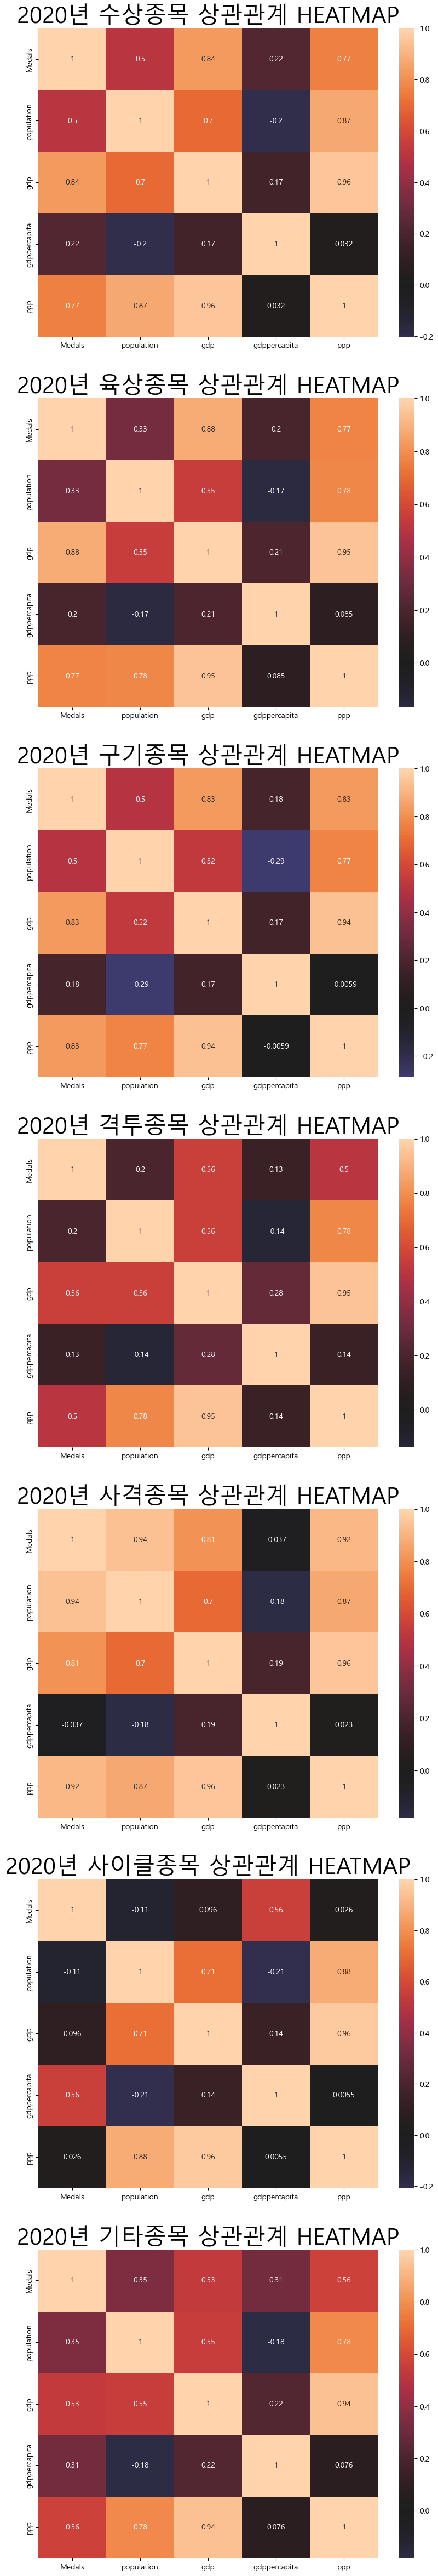

"\nlist1 = ['water','athletics','ball','fight','shoot','cycle','etc']\nfor i in range(7):\n    df_corr.loc[i] = df_+f'{list[i]}'+_20202[['Medals','population','gdp','gdppercapita','ppp']].corr().iloc[0,1:]\n\ndisplay(df_corr)\n"

In [123]:
# 2020년에 대한 분류된 종목에 대한 GDP, 인구 상관계수

fig,axes = plt.subplots(7,1,figsize=(10,60))
sns.heatmap(df_water_20202[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[0])
axes[0].set_title('2020년 수상종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_athletics_20202[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[1])
axes[1].set_title('2020년 육상종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_ball_20202[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[2])
axes[2].set_title('2020년 구기종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_fight_20202[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[3])
axes[3].set_title('2020년 격투종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_shoot_20202[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[4])
axes[4].set_title('2020년 사격종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_cycle_20202[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[5])
axes[5].set_title('2020년 사이클종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_etc_20202[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[6])
axes[6].set_title('2020년 기타종목 상관관계 HEATMAP',size=30)

plt.show()
'''
list1 = ['water','athletics','ball','fight','shoot','cycle','etc']
for i in range(7):
    df_corr.loc[i] = df_+f'{list[i]}'+_20202[['Medals','population','gdp','gdppercapita','ppp']].corr().iloc[0,1:]
    
display(df_corr)
'''

## 종목별로 나눠서 상관관계를 보니 그냥 중국, 미국이 잘하는 종목이 있으면 상관관계가 높게 나오고 아니면 낮게 나오는 듯하다.

In [125]:
df_water_20242 = df[df['Discipline'].isin(water_sports)]
df_athletics_20242 = df[df['Discipline'].isin(athletics)]
df_ball_20242 = df[df['Discipline'].isin(ball)]
df_fight_20242 = df[df['Discipline'].isin(fight)]
df_shoot_20242 = df[df['Discipline'].isin(shoot)]
df_cycle_20242 = df[df['Discipline'].isin(cycle)]
df_etc_20242 = df[df['Discipline'].isin(etc)]

# 연도와 나라에 대해 그룹화하고 메달 타입에 대해 원소 갯수를 카운트한다. 그리고 결측치는 0으로 바꿔준다. 
# Medals에 Gold, Silver, Bronze의 총 합을 넣어준다. 
# 모든 분류에 대해 데이터프레임을 생성해준다. 
df_water_20242 = df_water_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_water_20242['Medals'] = df_water_20242['Bronze']+df_water_20242['Silver']+df_water_20242['Gold']

df_athletics_20242 = df_athletics_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_athletics_20242['Medals'] = df_athletics_20242['Bronze']+df_athletics_20242['Silver']+df_athletics_20242['Gold']

df_ball_20242 = df_ball_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_ball_20242['Medals'] = df_ball_20242['Bronze']+df_ball_20242['Silver']+df_ball_20242['Gold']

df_fight_20242 = df_fight_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_fight_20242['Medals'] = df_fight_20242['Bronze']+df_fight_20242['Silver']+df_fight_20242['Gold']

df_shoot_20242 = df_shoot_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_shoot_20242['Medals'] = df_shoot_20242['Bronze']+df_shoot_20242['Silver']+df_shoot_20242['Gold']

df_cycle_20242 = df_cycle_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_cycle_20242['Medals'] = df_cycle_20242['Bronze']+df_cycle_20242['Silver']+df_cycle_20242['Gold']

df_etc_20242 = df_etc_20242.groupby(['Olympic_year','Committee'])['Medal_type'].value_counts().unstack().fillna(0)
df_etc_20242['Medals'] = df_etc_20242['Bronze']+df_etc_20242['Silver']+df_etc_20242['Gold']

# 그룹화한 데이터를 다시 reset_index()함으로써 연도와 나라를 다시 열로 바꿔준다.(차트를 만들기 쉽게하기 위해)
df_water_20242 = df_water_20242.reset_index()
df_athletics_20242 = df_athletics_20242.reset_index()
df_ball_20242 = df_ball_20242.reset_index()
df_fight_20242 = df_fight_20242.reset_index()
df_shoot_20242 = df_shoot_20242.reset_index()
df_cycle_20242 = df_cycle_20242.reset_index()
df_etc_20242 = df_etc_20242.reset_index()

# 2024년에 대해 종목을 나누고 총 메달 수에 대해 내림차순 정렬한다. 
df_water_20242 = df_water_20242.sort_values('Medals',ascending=False)
df_athletics_20242 = df_athletics_20242.sort_values('Medals',ascending=False)
df_ball_20242 = df_ball_20242.sort_values('Medals',ascending=False)
df_fight_20242 = df_fight_20242.sort_values('Medals',ascending=False)
df_shoot_20242 = df_shoot_20242.sort_values('Medals',ascending=False)
df_cycle_20242 = df_cycle_20242.sort_values('Medals',ascending=False)
df_etc_20242 = df_etc_20242.sort_values('Medals',ascending=False)


df_gdp2024 = df_gdp[['Country Name','2024']]
df_gdp2024 = df_gdp2024.rename(columns={'Country Name':'Committee','2024':'gdp'})

df_population2024 = df_population[['Country Name','2024']]
df_population2024 = df_population2024.rename(columns={'Country Name':'Committee','2024':'population'})

df_gdppercapita2024 = df_gdppercapita[['Country Name','2024']]
df_gdppercapita2024 = df_gdppercapita2024.rename(columns={'Country Name':'Committee','2024':'gdppercapita'})

df_ppp2024 = df_ppp[['Country Name','2024']]
df_ppp2024 = df_ppp2024.rename(columns={'Country Name':'Committee','2024':'ppp'})

# water에 대해 
df_water_20242 = pd.merge(df_water_20242,df_population2024,on='Committee',how='inner')
df_water_20242 = pd.merge(df_water_20242,df_gdp2024,on='Committee',how='inner')
df_water_20242 = pd.merge(df_water_20242,df_gdppercapita2024,on='Committee',how='inner')
df_water_20242 = pd.merge(df_water_20242,df_ppp2024,on='Committee',how='inner')

# athletics에 대해 
df_athletics_20242 = pd.merge(df_athletics_20242,df_population2024,on='Committee',how='inner')
df_athletics_20242 = pd.merge(df_athletics_20242,df_gdp2024,on='Committee',how='inner')
df_athletics_20242 = pd.merge(df_athletics_20242,df_gdppercapita2024,on='Committee',how='inner')
df_athletics_20242 = pd.merge(df_athletics_20242,df_ppp2024,on='Committee',how='inner')

# ball에 대해 
df_ball_20242 = pd.merge(df_ball_20242,df_population2024,on='Committee',how='inner')
df_ball_20242 = pd.merge(df_ball_20242,df_gdp2024,on='Committee',how='inner')
df_ball_20242 = pd.merge(df_ball_20242,df_gdppercapita2024,on='Committee',how='inner')
df_ball_20242 = pd.merge(df_ball_20242,df_ppp2024,on='Committee',how='inner')

# fight에 대해 
df_fight_20242 = pd.merge(df_fight_20242,df_population2024,on='Committee',how='inner')
df_fight_20242 = pd.merge(df_fight_20242,df_gdp2024,on='Committee',how='inner')
df_fight_20242 = pd.merge(df_fight_20242,df_gdppercapita2024,on='Committee',how='inner')
df_fight_20242 = pd.merge(df_fight_20242,df_ppp2024,on='Committee',how='inner')

# shoot에 대해 
df_shoot_20242 = pd.merge(df_shoot_20242,df_population2024,on='Committee',how='inner')
df_shoot_20242 = pd.merge(df_shoot_20242,df_gdp2024,on='Committee',how='inner')
df_shoot_20242 = pd.merge(df_shoot_20242,df_gdppercapita2024,on='Committee',how='inner')
df_shoot_20242 = pd.merge(df_shoot_20242,df_ppp2024,on='Committee',how='inner')

# cycle에 대해 
df_cycle_20242 = pd.merge(df_cycle_20242,df_population2024,on='Committee',how='inner')
df_cycle_20242 = pd.merge(df_cycle_20242,df_gdp2024,on='Committee',how='inner')
df_cycle_20242 = pd.merge(df_cycle_20242,df_gdppercapita2024,on='Committee',how='inner')
df_cycle_20242 = pd.merge(df_cycle_20242,df_ppp2024,on='Committee',how='inner')

# etc에 대해 
df_etc_20242 = pd.merge(df_etc_20242,df_population2024,on='Committee',how='inner')
df_etc_20242 = pd.merge(df_etc_20242,df_gdp2024,on='Committee',how='inner')
df_etc_20242 = pd.merge(df_etc_20242,df_gdppercapita2024,on='Committee',how='inner')
df_etc_20242 = pd.merge(df_etc_20242,df_ppp2024,on='Committee',how='inner')


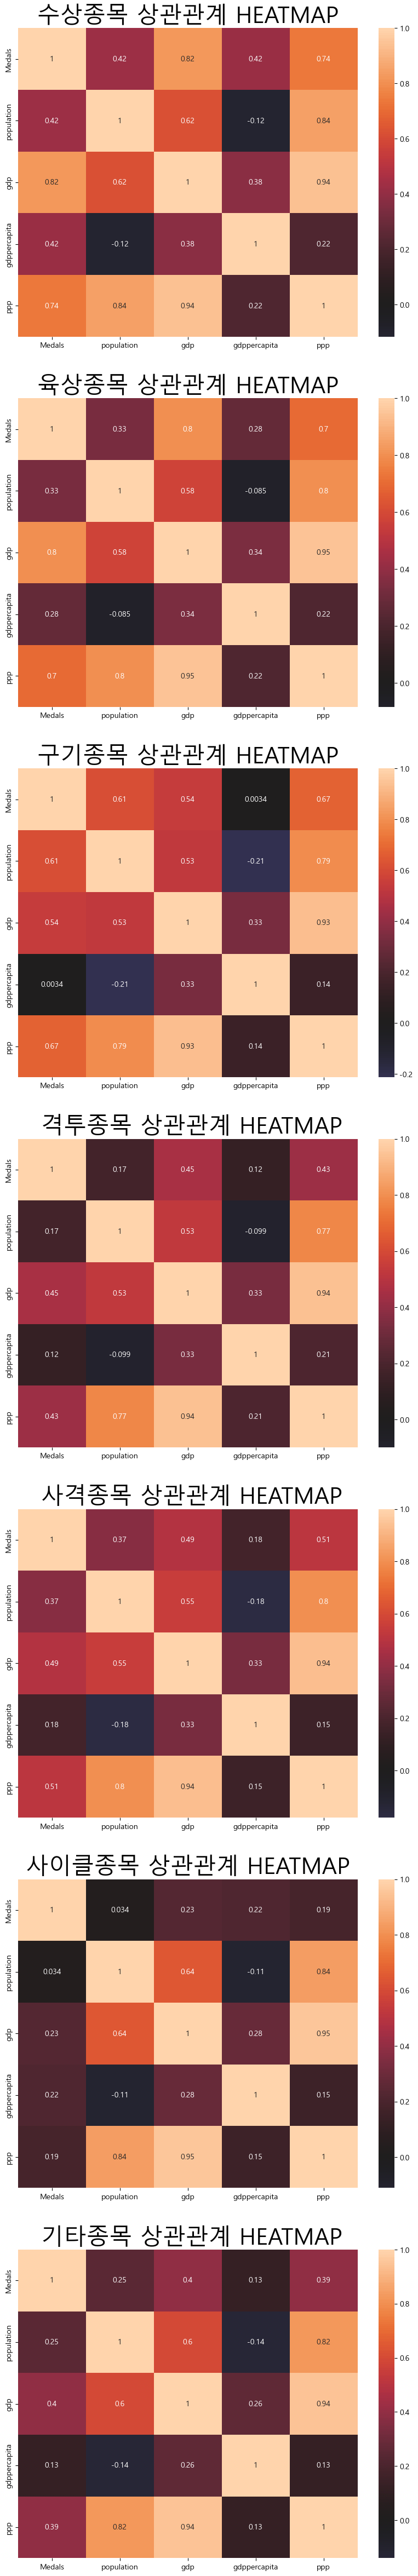

In [126]:
# 2020년에 대한 분류된 종목에 대한 GDP, 인구 상관계수

fig,axes = plt.subplots(7,1,figsize=(10,60))
sns.heatmap(df_water_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[0])
axes[0].set_title('수상종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_athletics_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[1])
axes[1].set_title('육상종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_ball_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[2])
axes[2].set_title('구기종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_fight_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[3])
axes[3].set_title(' 격투종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_shoot_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[4])
axes[4].set_title(' 사격종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_cycle_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[5])
axes[5].set_title('사이클종목 상관관계 HEATMAP',size=30)
sns.heatmap(df_etc_20242[['Medals','population','gdp','gdppercapita','ppp']].corr(),annot=True,center=0,ax=axes[6])
axes[6].set_title(' 기타종목 상관관계 HEATMAP',size=30)

plt.show()